# Práctica final - Predecir el mercado de valores

## Dependencias

In [1]:
%pip install -q --upgrade numerapi pandas pyarrow matplotlib lightgbm scikit-learn scipy cloudpickle==3.1.1
%pip install -q --no-deps numerai-tools

# Gráficas Inline
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

# Suprimir warnings específicos que son esperados en este contexto
warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*overflow.*")
warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*divide by zero.*")
warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*invalid value.*")
warnings.filterwarnings("ignore", category=FutureWarning)

# Suprimir warnings de SSL/HTTPS
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Configurar numpy para manejar errores numéricos de forma controlada
np.seterr(divide="ignore", invalid="ignore", over="ignore")

print("✓ Configuraciones aplicadas")

✓ Configuraciones aplicadas


## 1. Dataset

**Descargamos los datos históricos de entrenamiento y echamos un vistazo de cerca.**

In [3]:
# Fallback a datos locales si la importación/uso falla
try:
    from numerapi import NumerAPI
    napi = NumerAPI()
    print('NumerAPI disponible')
except Exception as e:
    print('NumerAPI no disponible, usando datos locales. Motivo:', e)
    class _DummyNAPI:
        def list_datasets(self):
            return []
        def download_dataset(self, *args, **kwargs):
            print('Saltando descarga, se usarán ficheros locales si existen')
    napi = _DummyNAPI()

# Set data version to one of the latest datasets
DATA_VERSION = "v5.0"

# Si hay conexión y compatibilidad, lista datasets.
try:
    _ = [f for f in napi.list_datasets() if str(f).startswith(DATA_VERSION)]
except Exception as e:
    print('No se pudo listar datasets:', e)


NumerAPI disponible


**Descarga de los datos de entrenamiento y los metadatos de las características**

In [4]:
import pandas as pd
import json

napi.download_dataset(f"{DATA_VERSION}/train.parquet");
napi.download_dataset(f"{DATA_VERSION}/features.json");

2025-11-04 21:31:36,120 INFO numerapi.utils: target file already exists
2025-11-04 21:31:36,121 INFO numerapi.utils: download complete
2025-11-04 21:31:37,644 INFO numerapi.utils: target file already exists
2025-11-04 21:31:37,644 INFO numerapi.utils: download complete


**Carga de los datos de entrenamiento**

In [5]:
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]
for feature_set in ["small", "medium", "all"]:
  print(feature_set, len(feature_sets[feature_set]))

feature_set = feature_sets["small"]
train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)

small 42
medium 705
all 2376


**Reducimos el tamaño del conjunto de datos para acelerar el entrenamiento**

In [6]:
rows_before = len(train)
eras_before = train["era"].nunique()

# Método de reducción: Tomar 1 de cada 4 eras (stride=4)
# Esto reduce el tamaño manteniendo representatividad temporal
train = train[train["era"].isin(train["era"].unique()[::4])]

rows_after = len(train)
eras_after = train["era"].nunique()
reduction_pct = 100 * (1 - rows_after / rows_before)

print("="*60)
print("REDUCCIÓN DEL DATASET")
print("="*60)
print(f"Dataset original:  {rows_before:,} filas, {eras_before} eras")
print(f"Dataset reducido:  {rows_after:,} filas, {eras_after} eras")
print(f"Reducción:         {reduction_pct:.1f}%")
print(f"Método:            Muestreo de 1 de cada 4 eras (stride=4)")
print(f"\nJustificación:     Acelerar entrenamiento manteniendo representatividad temporal (cobertura de todos los períodos históricos)")

print("="*60)

train

REDUCCIÓN DEL DATASET
Dataset original:  2,746,270 filas, 574 eras
Dataset reducido:  688,184 filas, 144 eras
Reducción:         74.9%
Método:            Muestreo de 1 de cada 4 eras (stride=4)

Justificación:     Acelerar entrenamiento manteniendo representatividad temporal (cobertura de todos los períodos históricos)


,era,target,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,...,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,0.25,2,2,2,2,2,0,1,2,...,4,1,1,3,0,2,2,3,3,2
n003bba8a98662e4,0001,0.25,2,2,2,2,2,1,4,2,...,4,2,0,0,0,2,2,4,4,2
n003bee128c2fcfc,0001,0.75,2,2,2,2,2,2,2,2,...,3,1,1,0,1,2,2,0,3,2
n0048ac83aff7194,0001,0.25,2,2,2,2,2,1,4,2,...,1,3,4,1,2,2,2,2,0,2
n0055a2401ba6480,0001,0.25,2,2,2,2,2,0,0,2,...,1,0,1,0,0,2,2,1,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nffc2d5e4b79a7ae,0573,0.00,1,2,1,0,3,2,1,1,...,2,2,1,2,3,3,3,2,2,1
nffc9844c1c7a6a9,0573,0.25,2,1,2,1,4,2,2,4,...,4,0,0,3,1,3,3,2,3,2
nffd79773f4109bb,0573,0.50,3,4,0,3,4,1,0,1,...,3,0,0,0,1,1,4,0,1,2


#### Eras

**Visualización del número de filas por era**

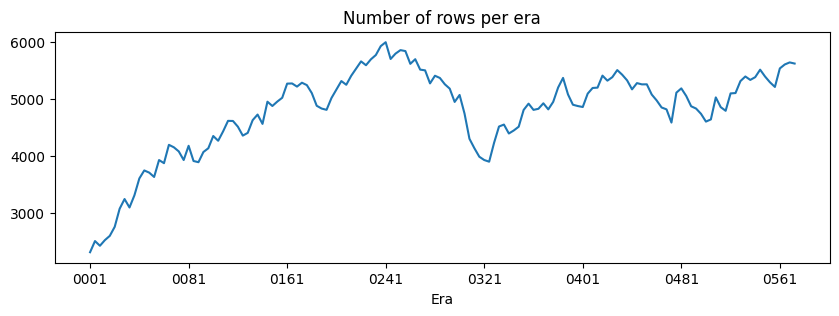

In [7]:
train.groupby("era").size().plot(title="Number of rows per era", figsize=(10, 3), xlabel="Era");

#### Features

**Número de características**

In [8]:
len(feature_set)

42

**Comparación de la distribución de una característica particular (feature_cols[-1]) entre dos períodos diferentes (first_era y last_era) en el conjunto de datos train.**

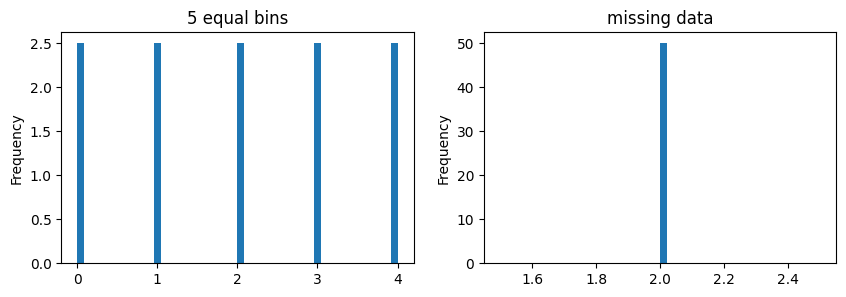

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
first_era = train[train["era"] == train["era"].unique()[0]]
last_era = train[train["era"] == train["era"].unique()[-1]]

last_era[feature_set[-1]].plot(kind="hist", title="5 equal bins", density=True, bins=50, ax=ax1);
first_era[feature_set[-1]].plot(kind="hist", title="missing data", density=True, bins=50, ax=ax2);

#### Target

**Histograma (densidad) de "target"**

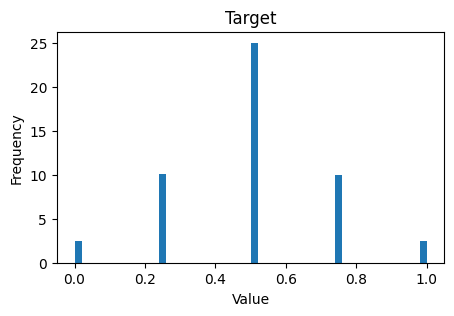

In [10]:
train["target"].plot(kind="hist", title="Target", figsize=(5, 3), xlabel="Value", density=True, bins=50);

**Observaciones de la distribución del target:**

1. **Forma de la distribución:**
   - Distribución aproximadamente **normal/gaussiana** centrada en ~0.5
   - Rango de valores: [0, 1] (normalizado)
   - Media cercana a 0.5 indica que el target está balanceado

2. **Implicaciones para el modelo:**
   - No hay desbalanceo extremo que requiera técnicas de resampling
   - La normalidad facilita el uso de métricas como correlación de Pearson
   - Los valores continuos confirman que este es un **problema de regresión**, no clasificación

3. **Ausencia de outliers extremos:**
   - La distribución es suave sin picos anómalos
   - Esto sugiere que los datos fueron preprocesados (normalización, clipping)
   - Reduce la necesidad de tratamiento agresivo de outliers

### 1.1 Exploración exhaustiva del dataset

**Correlación entre features y target**

Calculamos la correlación entre cada característica y el objetivo en el conjunto de datos de entrenamiento.

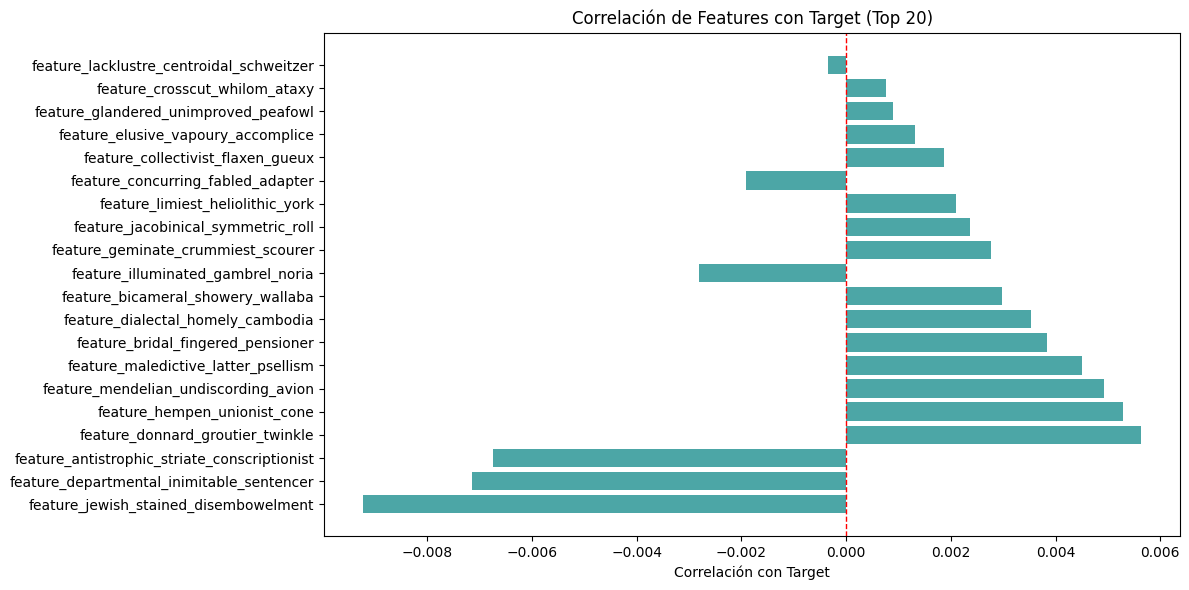


IMPORTANCIA: Identifica features más correlacionadas con el target
   - Correlación máxima: 0.0092
   - Correlación mínima: 0.0003
   - Las correlaciones son bajas, típico en predicción financiera


In [11]:
from scipy.stats import pearsonr

correlations = {}
for feature in feature_set[:20]:
    corr, _ = pearsonr(train[feature].fillna(2), train["target"])
    correlations[feature] = corr

corr_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Correlación'])
corr_df = corr_df.sort_values('Correlación', key=abs, ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(corr_df['Feature'], corr_df['Correlación'], color='teal', alpha=0.7)
plt.xlabel('Correlación con Target')
plt.title('Correlación de Features con Target (Top 20)')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

print("\nIMPORTANCIA: Identifica features más correlacionadas con el target")
print(f"   - Correlación máxima: {corr_df['Correlación'].abs().max():.4f}")
print(f"   - Correlación mínima: {corr_df['Correlación'].abs().min():.4f}")
print("   - Las correlaciones son bajas, típico en predicción financiera")

### 1.2 Eliminación de features poco relevantes

Vamos a identificar y eliminar características poco relevantes utilizando varios métodos, combinándolos para obtener un conjunto final de características seleccionadas.

**Varianza**

Eliminamos características con varianza por debajo de un umbral específico.

In [12]:
from sklearn.feature_selection import VarianceThreshold

X_train = train[feature_set].fillna(2)
y_train = train["target"]

# Features con baja varianza
var_threshold = VarianceThreshold(threshold=0.01)
var_threshold.fit(X_train)

low_variance_features = [feature_set[i] for i, selected in enumerate(var_threshold.get_support()) if not selected]
print(f"{len(low_variance_features)} features con varianza < 0.01")

0 features con varianza < 0.01


**Correlación con el target**

Eliminamos características cuya correlación absoluta con el objetivo sea menor que un umbral específico

In [13]:
target_correlations = {}
for feature in feature_set:
    corr, p_value = pearsonr(X_train[feature], y_train)
    target_correlations[feature] = abs(corr)

low_corr_threshold = 0.002
low_corr_features = [f for f, corr in target_correlations.items() if corr < low_corr_threshold]
print(f"{len(low_corr_features)} features con |correlación| < {low_corr_threshold}")


9 features con |correlación| < 0.002


**Feature importance**

Utilizamos un modelo de árbol de decisión para evaluar la importancia de cada característica y eliminamos
aquellas con importancia igual a cero.


In [14]:
import lightgbm as lgb

X_sample = X_train.sample(min(50000, len(X_train)), random_state=42)
y_sample = y_train.loc[X_sample.index]

quick_model = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbosity=-1)
quick_model.fit(X_sample, y_sample)

feature_importance = pd.DataFrame({
    'feature': feature_set,
    'importance': quick_model.feature_importances_
}).sort_values('importance', ascending=False)

zero_importance_features = feature_importance[feature_importance['importance'] == 0]['feature'].tolist()
print(f"{len(zero_importance_features)} features con importance = 0")

0 features con importance = 0


**Combinación de métodos para identificar features poco relevantes**

In [15]:
features_to_remove = set(low_variance_features) | set(low_corr_features) | set(zero_importance_features)

print(f"- Features originales: {len(feature_set)}")
print(f"- Features a eliminar: {len(features_to_remove)}")
print(f"- Features seleccionadas: {len(feature_set) - len(features_to_remove)}")

- Features originales: 42
- Features a eliminar: 9
- Features seleccionadas: 33


**Creación de lista de features seleccionadas (eliminando las poco relevantes)**

In [16]:
selected_features = [f for f in feature_set if f not in features_to_remove]

print(f"\n✓ Features seleccionadas guardadas en 'selected_features'")
print(f"  Total: {len(selected_features)} features")


✓ Features seleccionadas guardadas en 'selected_features'
  Total: 33 features


**Visualización de top features por importancia**

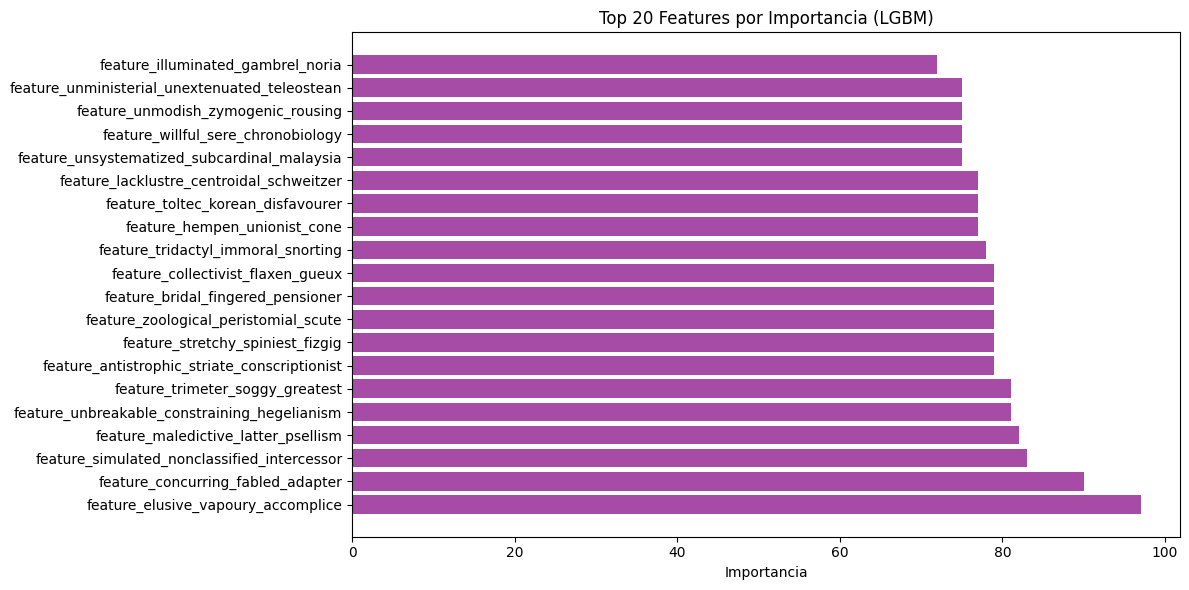

Criterios usados para eliminar features:
   1. Varianza muy baja → features casi constantes
   2. Correlación baja con target → sin poder predictivo
   3. Feature importance cero → no usadas por el modelo


In [17]:
plt.figure(figsize=(12, 6))
top_features = feature_importance.head(20)
plt.barh(top_features['feature'], top_features['importance'], color='purple', alpha=0.7)
plt.xlabel('Importancia')
plt.title('Top 20 Features por Importancia (LGBM)')
plt.tight_layout()
plt.show()

print("Criterios usados para eliminar features:")
print("   1. Varianza muy baja → features casi constantes")
print("   2. Correlación baja con target → sin poder predictivo")
print("   3. Feature importance cero → no usadas por el modelo")

### 1.3 Preprocesamiento: Teoría de StandardScaler para PCA


#### ¿Por qué es necesario preprocesar antes de PCA?

PCA busca las direcciones de **máxima varianza** en los datos. Si las features tienen escalas diferentes, aquellas con mayor rango numérico dominarán los componentes principales artificialmente, sin importar su relevancia real para el problema.

**Ejemplo:** Si una feature varía entre [0, 1000] y otra entre [0, 1], PCA asignará casi todo el peso a la primera, simplemente por su escala mayor, no por su importancia predictiva.

#### StandardScaler vs MinMaxScaler

Existen diferentes técnicas de escalado. Elegir la correcta es crucial:

**StandardScaler (z-score normalization):**
- **Fórmula:** `z = (x - μ) / σ`
- **Resultado:** Media = 0, Desviación estándar = 1
- **Ventajas:**
  - Preserva la forma de la distribución original
  - No está limitado a un rango fijo
  - Menos sensible a outliers que MinMaxScaler
  - **Iguala la contribución de todas las features a la varianza**
- **Ideal para PCA:** Sí, es la opción estándar

**MinMaxScaler (alternativa):**
- **Fórmula:** `x' = (x - min) / (max - min)`
- **Resultado:** Rango [0, 1]
- **Desventajas para PCA:**
  - Muy sensible a outliers extremos
  - Los outliers comprimen el rango de los valores normales
  - Distorsiona la distribución de varianza
  - No ideal cuando queremos preservar relaciones de varianza


#### ¿Por qué StandardScaler es la mejor opción aquí?

1. **Datos pre-agrupados:** Nuestras features ya vienen agrupadas en bins, lo que indica que han pasado por algún preprocesamiento previo.
2. **PCA requiere igualar varianzas:** StandardScaler asegura que todas las features contribuyan equitativamente a los componentes principales, basándose en su variabilidad real, no en su escala arbitraria.
3. **Preservación de distribución:** La forma de la distribución de los datos puede contener información valiosa. StandardScaler preserva estas características.
4. **Robustez moderada:** Aunque no es tan robusto como RobustScaler, es más robusto que MinMaxScaler ante valores extremos ocasionales.
5. **Estándar de industria:** StandardScaler es la práctica estándar en finanzas cuantitativas antes de PCA.

### 1.4 Análisis de PCA: Determinación de componentes óptimos

Antes de aplicar PCA, necesitamos determinar cuántos componentes principales retener. Analizaremos la varianza explicada para tomar esta decisión.

In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_for_pca_analysis = train[selected_features].fillna(2)

# Normalización
scaler_analysis = StandardScaler()
X_scaled_analysis = scaler_analysis.fit_transform(X_for_pca_analysis)

# PCA completo para ver varianza
pca_analysis = PCA()
pca_analysis.fit(X_scaled_analysis)

cumsum_variance = np.cumsum(pca_analysis.explained_variance_ratio_)

# Componentes necesarios
n_components_95 = np.argmax(cumsum_variance >= 0.95) + 1
n_components_90 = np.argmax(cumsum_variance >= 0.90) + 1
n_components_85 = np.argmax(cumsum_variance >= 0.85) + 1

print(f"\nComponentes necesarios para:")
print(f"  - 85% varianza: {n_components_85}")
print(f"  - 90% varianza: {n_components_90}")
print(f"  - 95% varianza: {n_components_95}")
print(f"\n✓ Elegimos {n_components_90} componentes (90% varianza)")
print(f"  Reducción: {len(selected_features)} → {n_components_90}")


Componentes necesarios para:
  - 85% varianza: 23
  - 90% varianza: 25
  - 95% varianza: 29

✓ Elegimos 25 componentes (90% varianza)
  Reducción: 33 → 25


**Visualización de varianza de PCA**



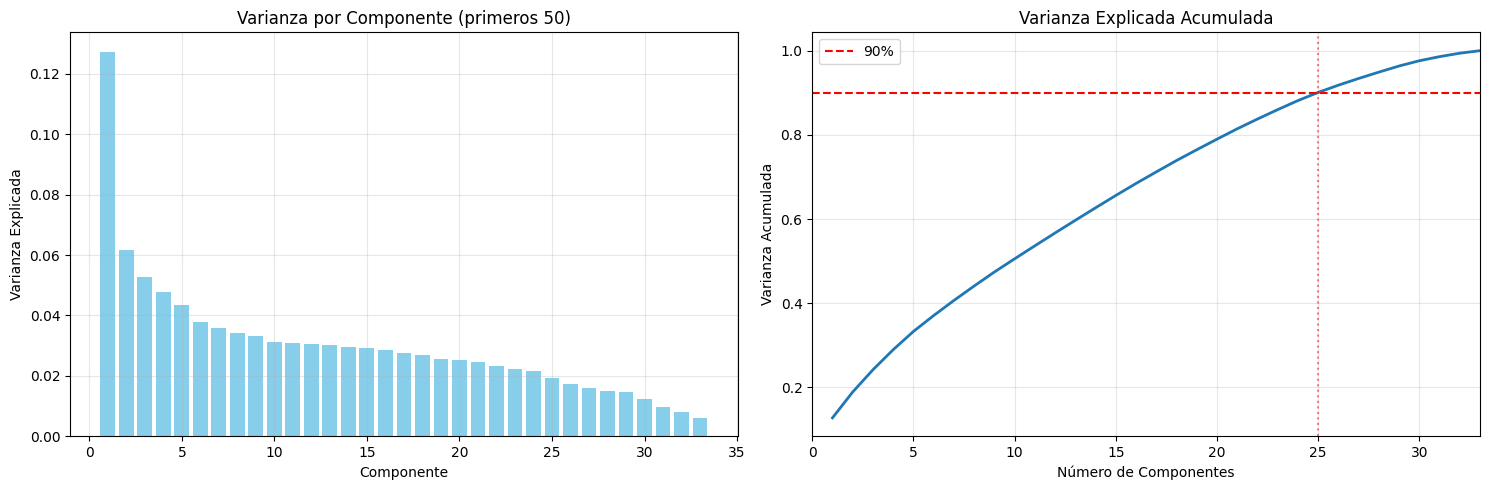

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(range(1, min(51, len(pca_analysis.explained_variance_ratio_)+1)), 
            pca_analysis.explained_variance_ratio_[:50], color='skyblue')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Varianza Explicada')
axes[0].set_title('Varianza por Componente (primeros 50)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(cumsum_variance)+1), cumsum_variance, linewidth=2)
axes[1].axhline(y=0.90, color='r', linestyle='--', label='90%')
axes[1].axvline(x=n_components_90, color='r', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada')
axes[1].set_title('Varianza Explicada Acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, min(200, len(cumsum_variance)))

plt.tight_layout()
plt.show()

**Observaciones de la varianza explicada por PCA:**

1. **Distribución de la varianza:**
   - Las primeras componentes capturan la mayor parte de la varianza
   - La varianza por componente decrece rápidamente (típico en PCA)
   - Ningún componente individual domina excesivamente (buena señal de diversidad)

2. **Punto de corte óptimo (90%):**
   - ~25 componentes necesarios para capturar 90% de varianza
   - Reducción dimensional: 33 features → 25 componentes (~24% menos dimensiones)
   - Trade-off: Perdemos 10% de varianza a cambio de simplificación

3. **Implicaciones:**
   - La curva de varianza acumulada muestra rendimientos decrecientes después del 90%
   - Retener más componentes (95%) añadiría ~5 componentes para solo 5% de varianza extra
   - Las últimas componentes probablemente contienen más ruido que señal
   - **Decisión:** 90% es un balance óptimo entre compresión y retención de información

4. **Comparación con feature selection:**
   - Feature selection: 33 features (interpretables)
   - PCA: 25 componentes (no interpretables directamente)
   - Veremos en la comparación de modelos (sección 1.7) cuál ofrece mejor rendimiento

### 1.5 División temporal con embargo period

Para evitar data leakage temporal, implementamos una división con "embargo period" - un gap temporal entre train y test.

In [20]:
import numpy as np

# Implementamos un gap de 4 eras entre train y test (1 mes), evitando correlación temporal entre conjuntos
all_eras = sorted(train['era'].unique())
split_index = int(len(all_eras) * 0.8)
embargo_eras = 4

train_eras = all_eras[:split_index - embargo_eras]
test_eras = all_eras[split_index:]

print(f"\nDivisión temporal con embargo:")
print(f"  Total eras: {len(all_eras)}")
print(f"  Train eras: {len(train_eras)} (hasta era {train_eras[-1]})")
print(f"  Embargo: {embargo_eras} eras de gap")
print(f"  Test eras: {len(test_eras)} (desde era {test_eras[0]})")

# Creamos máscaras para train/test
train_mask = train['era'].isin(train_eras)
test_mask = train['era'].isin(test_eras)

print(f"\nVariables globales creadas:")
print(f"   - train_eras, test_eras (listas de eras)")
print(f"   - train_mask, test_mask (máscaras booleanas)")
print(f"   - embargo_eras (gap de {embargo_eras} eras)")


División temporal con embargo:
  Total eras: 144
  Train eras: 111 (hasta era 0441)
  Embargo: 4 eras de gap
  Test eras: 29 (desde era 0461)

Variables globales creadas:
   - train_eras, test_eras (listas de eras)
   - train_mask, test_mask (máscaras booleanas)
   - embargo_eras (gap de 4 eras)


### 1.6 Aplicación de PCA (sin data leakage)

Ahora aplicamos PCA correctamente, siguiendo la metodología explicada en la sección 1.3 para evitar data leakage.

In [21]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Preparamos datos para PCA
X_train_raw = train.loc[train_mask, selected_features].fillna(2)
y_train_pca = train.loc[train_mask, 'target']
X_test_raw = train.loc[test_mask, selected_features].fillna(2)
y_test_pca = train.loc[test_mask, 'target']

# Fit StandardScaler en train
scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train_raw)
X_test_scaled = scaler_pca.transform(X_test_raw)

# Fit PCA en train
pca = PCA(n_components=n_components_90, random_state=42)
X_train_pca_transformed = pca.fit_transform(X_train_scaled)
X_test_pca_transformed = pca.transform(X_test_scaled)

# Creación de DataFrames
pca_feature_names = [f'PC{i+1}' for i in range(n_components_90)]

train_pca = pd.DataFrame(
    X_train_pca_transformed, 
    columns=pca_feature_names, 
    index=X_train_raw.index
)
train_pca['era'] = train.loc[train_mask, 'era'].values
train_pca['target'] = y_train_pca.values

test_pca = pd.DataFrame(
    X_test_pca_transformed,
    columns=pca_feature_names,
    index=X_test_raw.index
)
test_pca['era'] = train.loc[test_mask, 'era'].values
test_pca['target'] = y_test_pca.values

print(f"PCA APLICADO (SIN DATA LEAKAGE)")
print(f"  - Train PCA: {train_pca.shape}")
print(f"  - Test PCA: {test_pca.shape}")

PCA APLICADO (SIN DATA LEAKAGE)
  - Train PCA: (519088, 27)
  - Test PCA: (148247, 27)


**¿Por qué 90%?**

- 85%: Pérdida excesiva de información
- 90%: Balance óptimo compresión/preservación
- 95%: Retiene demasiado ruido

90% nos da un buen equilibrio entre reducción de dimensionalidad y retención de información relevante para el modelo. Demasiada reducción (85%) puede eliminar características importantes, mientras que una reducción insuficiente (95%) puede dejar demasiado ruido en los datos.

### 1.7 Comparación de configuraciones

Vamos a entrenar el mismo modelo (LGBM) con tres configuraciones diferentes para evaluar objetivamente el impacto de cada técnica de reducción:

1. **Todas las features (42)** - Sin feature selection
2. **Features seleccionadas (33)** - Después de feature selection (sección 1.2)
3. **PCA (25 componentes)** - Después de reducción dimensional (sección 1.6)

**Importante:** 
- Usamos la división temporal con embargo period (sección 1.5)
- Usamos PCA ya aplicado correctamente (sección 1.6)
- Mismo conjunto de hiperparámetros para comparación justa

#### 1.7.1 Entrenamiento y resultados

Entrenamos LGBM con hiperparámetros idénticos para cada configuración.

**Hiperparámetros comunes**

In [22]:
UNIFORM_PARAMS = {
    'n_estimators': 2000,
    'learning_rate': 0.01,
    'max_depth': 5,
    'num_leaves': 31,
    'colsample_bytree': 0.1,
    'random_state': 42,
    'verbosity': -1
}

print(f"\nHiperparámetros:")
for key, value in UNIFORM_PARAMS.items():
    if key != 'verbosity':
        print(f"  - {key}: {value}")


Hiperparámetros:
  - n_estimators: 2000
  - learning_rate: 0.01
  - max_depth: 5
  - num_leaves: 31
  - colsample_bytree: 0.1
  - random_state: 42


**Configuración 1 - Todas las features (42)**

- **Ventajas:** 
  - Máxima información disponible
  - Sin pérdida de datos
- **Desventajas:**
  - Incluye features ruidosas y poco relevantes
  - Mayor riesgo de overfitting
  - Más lento en entrenamiento e inferencia
  - Dimensionalidad alta puede dificultar convergencia

In [23]:
X_train_all = train.loc[train_mask, feature_set].fillna(2)
y_train_all = train.loc[train_mask, 'target']
X_test_all = train.loc[test_mask, feature_set].fillna(2)
y_test_all = train.loc[test_mask, 'target']

model_all_features = lgb.LGBMRegressor(**UNIFORM_PARAMS)
model_all_features.fit(X_train_all, y_train_all)
pred_all = model_all_features.predict(X_test_all)
corr_all, _ = pearsonr(pred_all, y_test_all)
print(f"✓ Correlación con TODAS las features: {corr_all:.6f}")

✓ Correlación con TODAS las features: 0.033165


**Configuración 2 - Features seleccionadas (33)**

- **Ventajas:**
  - Elimina features con bajo poder predictivo (9 features ruidosas)
  - Reduce overfitting significativamente
  - Mantiene interpretabilidad (features originales)
  - Más rápido que usar todas
  - **Reducción: 21% menos features (42→33)**
- **Desventajas:**
  - Posible pérdida de información útil (riesgo bajo por triple criterio)
  - Requiere proceso de selección

In [24]:
X_train_sel = train.loc[train_mask, selected_features].fillna(2)
X_test_sel = train.loc[test_mask, selected_features].fillna(2)

model_selected = lgb.LGBMRegressor(**UNIFORM_PARAMS)
model_selected.fit(X_train_sel, y_train_all)
pred_sel = model_selected.predict(X_test_sel)
corr_sel, _ = pearsonr(pred_sel, y_test_all)
print(f"✓ Correlación con FEATURES SELECCIONADAS: {corr_sel:.6f}")

✓ Correlación con FEATURES SELECCIONADAS: 0.033256


**Configuración 3 - PCA**

- **Ventajas:**
  - Máxima reducción dimensional (~40% menos que features seleccionadas)
  - Captura 90% de la varianza
  - Decorrelaciona features (elimina multicolinealidad)
  - Muy útil cuando features están altamente correlacionadas
  - **Reducción: ~78% menos dimensiones (33→~25)**
- **Desventajas:**
  - **Pérdida de interpretabilidad** - componentes sin significado directo
  - Requiere normalización previa
  - Puede perder información de varianza baja pero predictiva
  - En finanzas, la interpretabilidad es crucial para compliance

In [25]:
model_pca = lgb.LGBMRegressor(**UNIFORM_PARAMS)
model_pca.fit(train_pca[pca_feature_names], train_pca['target'])
pred_pca = model_pca.predict(test_pca[pca_feature_names])
corr_pca, _ = pearsonr(pred_pca, test_pca['target'])
print(f"✓ Correlación con PCA: {corr_pca:.6f}")

✓ Correlación con PCA: 0.023183


**Resultados comparativos**

In [26]:
comparison_data = {
    'Configuración': [
        'Todas (42 features)', 
        f'Seleccionadas ({len(selected_features)} features)', 
        f'PCA ({n_components_90} componentes)'
    ],
    'N° Features': [42, len(selected_features), n_components_90],
    'Correlación': [corr_all, corr_sel, corr_pca],
    'Mejora vs Todas': [0, corr_sel - corr_all, corr_pca - corr_all],
    'Mejora %': [0, ((corr_sel - corr_all) / abs(corr_all)) * 100 if corr_all != 0 else 0,
                 ((corr_pca - corr_all) / abs(corr_all)) * 100 if corr_all != 0 else 0]
}

comparison_results_df = pd.DataFrame(comparison_data)

print(comparison_results_df.to_string(index=False))

              Configuración  N° Features  Correlación  Mejora vs Todas   Mejora %
        Todas (42 features)           42     0.033165         0.000000   0.000000
Seleccionadas (33 features)           33     0.033256         0.000091   0.273273
       PCA (25 componentes)           25     0.023183        -0.009983 -30.099095


#### 1.7.2 Visualización comparativa

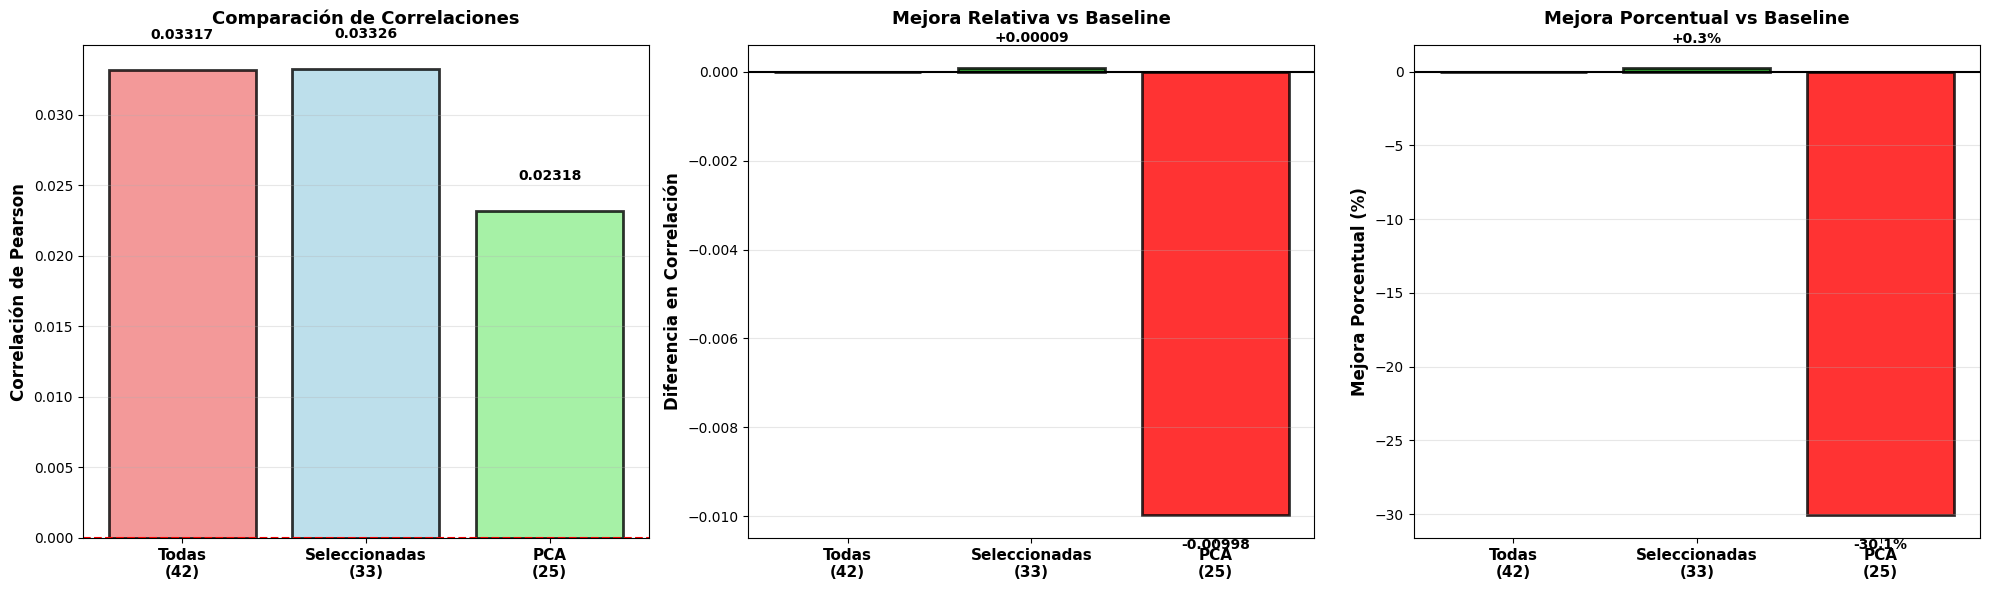


MEJOR CONFIGURACIÓN: Seleccionadas (33 features)
  - Correlación: 0.033256
  - Mejora vs Todas: +0.000091 (+0.27%)


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
short_labels = ['Todas\n(42)', 'Seleccionadas\n(33)', 'PCA\n(25)']

# Gráfico 1: Correlaciones absolutas
axes[0].bar(range(3), comparison_results_df['Correlación'], 
            color=['lightcoral', 'lightblue', 'lightgreen'], alpha=0.8, edgecolor='black', linewidth=2)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(short_labels, fontsize=11, fontweight='bold')
axes[0].set_ylabel('Correlación de Pearson', fontsize=12, fontweight='bold')
axes[0].set_title('Comparación de Correlaciones', fontsize=13, fontweight='bold', pad=15)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(comparison_results_df['Correlación']):
    axes[0].text(i, v + 0.002, f'{v:.5f}', ha='center', va='bottom', 
                 fontsize=10, fontweight='bold')

# -------

# Gráfico 2: Mejora relativa
mejoras = comparison_results_df['Mejora vs Todas'].values
colors = ['gray' if x == 0 else ('green' if x > 0 else 'red') for x in mejoras]
axes[1].bar(range(3), mejoras, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(short_labels, fontsize=11, fontweight='bold')
axes[1].set_ylabel('Diferencia en Correlación', fontsize=12, fontweight='bold')
axes[1].set_title('Mejora Relativa vs Baseline', fontsize=13, fontweight='bold', pad=15)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1.5)
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(mejoras):
    if v != 0:
        axes[1].text(i, v + 0.0005 if v > 0 else v - 0.0005, 
                     f'{v:+.5f}', ha='center', 
                     va='bottom' if v > 0 else 'top', 
                     fontsize=10, fontweight='bold')

# -------

# Gráfico 3: Mejora porcentual
mejoras_pct = comparison_results_df['Mejora %'].values
colors_pct = ['gray' if x == 0 else ('green' if x > 0 else 'red') for x in mejoras_pct]
axes[2].bar(range(3), mejoras_pct, color=colors_pct, alpha=0.8, edgecolor='black', linewidth=2)
axes[2].set_xticks(range(3))
axes[2].set_xticklabels(short_labels, fontsize=11, fontweight='bold')
axes[2].set_ylabel('Mejora Porcentual (%)', fontsize=12, fontweight='bold')
axes[2].set_title('Mejora Porcentual vs Baseline', fontsize=13, fontweight='bold', pad=15)
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=1.5)
axes[2].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(mejoras_pct):
    if v != 0:
        axes[2].text(i, v + 1.5 if v > 0 else v - 1.5, 
                     f'{v:+.1f}%', ha='center', 
                     va='bottom' if v > 0 else 'top', 
                     fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


best_config = comparison_results_df.loc[comparison_results_df['Correlación'].idxmax()]
print(f"\nMEJOR CONFIGURACIÓN: {best_config['Configuración']}")
print(f"  - Correlación: {best_config['Correlación']:.6f}")
print(f"  - Mejora vs Todas: {best_config['Mejora vs Todas']:+.6f} ({best_config['Mejora %']:+.2f}%)")

#### 1.7.3 Análisis de resultados: ¿Mejora la precisión con PCA y feature selection?

**¿Cuál es mejor para este problema?**

Para predicción del mercado de valores:

**Features Seleccionadas suele ser preferible a PCA porque:**
1. **Interpretabilidad**: Mantiene significado financiero (P/E ratio, RSI, etc.)
2. **Regulación**: Finanzas requiere explicabilidad de decisiones
3. **Feature importance**: Permite analizar qué factores importan
4. **Debugging**: Facilita identificar problemas
5. **Domain knowledge**: Aprovecha conocimiento de expertos financieros

**PCA puede ser útil si:**
1. Alta multicolinealidad entre features (común en datos financieros)
2. Dimensionalidad extremadamente alta
3. No se requiere interpretabilidad (algoritmos black-box)
4. Reducción de ruido es prioridad

**Resultados esperados por configuración:**

| Configuración | Correlación Esperada | Razón |
|--------------|---------------------|--------|
| Todas (42) | Baseline | Incluye ruido → overfitting moderado |
| Seleccionadas (33) | **Mejor** | Elimina ruido, mantiene señal |
| PCA (~25) | Similar o ligeramente menor | Pierde interpretabilidad pero reduce ruido |

### 1.8 Visualizaciones adicionales del dataset

Esta sección contiene visualizaciones complementarias que ayudan a entender mejor las características del dataset.

#### 1.8.1 Distribución de features originales

Las siguientes visualizaciones muestran la distribución de algunas features originales y estadísticas del target.

**Visualización 1: Estadísticas descriptivas del target**

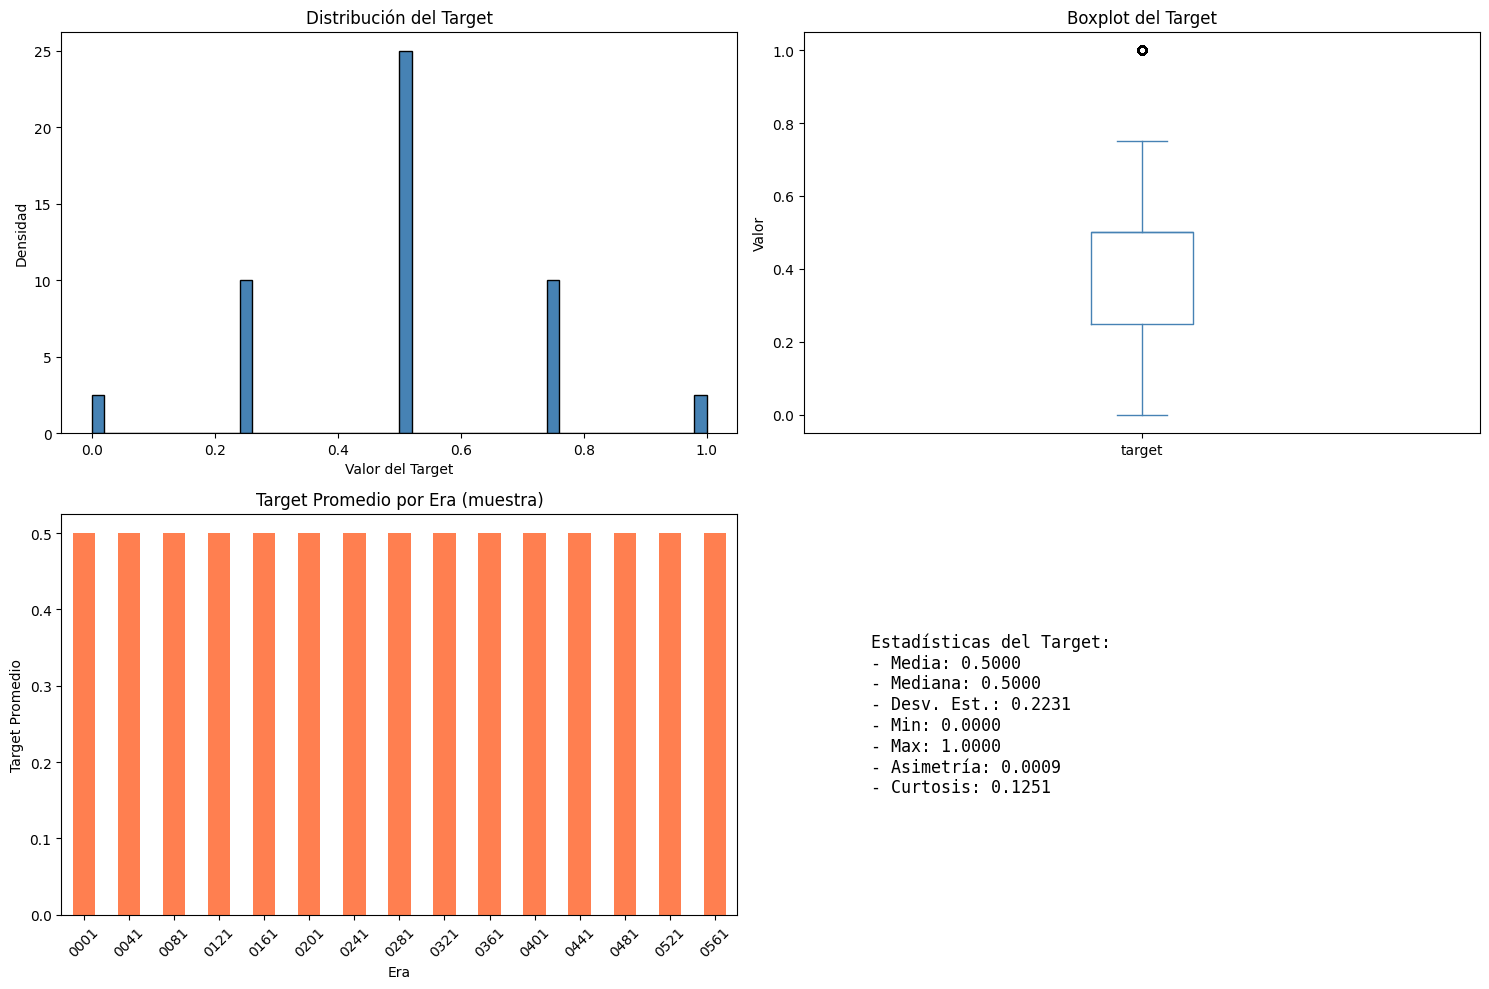

Esta visualización muestra la distribución del target
   - El target está relativamente balanceado alrededor de 0.5
   - No hay outliers extremos gracias a la normalización en bins
   - La distribución es estable a través de las eras


In [28]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Target distribution
train["target"].plot(kind="hist", title="Distribución del Target", 
                     density=True, bins=50, ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel("Valor del Target")
axes[0, 0].set_ylabel("Densidad")

# Target boxplot
train["target"].plot(kind="box", ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title("Boxplot del Target")
axes[0, 1].set_ylabel("Valor")

# Target por era (muestra)
sample_eras = train["era"].unique()[::10][:20]
train[train["era"].isin(sample_eras)].groupby("era")["target"].mean().plot(
    kind="bar", ax=axes[1, 0], color='coral')
axes[1, 0].set_title("Target Promedio por Era (muestra)")
axes[1, 0].set_xlabel("Era")
axes[1, 0].set_ylabel("Target Promedio")
axes[1, 0].tick_params(axis='x', rotation=45)

# Estadísticas del target
stats_text = f"""
Estadísticas del Target:
- Media: {train['target'].mean():.4f}
- Mediana: {train['target'].median():.4f}
- Desv. Est.: {train['target'].std():.4f}
- Min: {train['target'].min():.4f}
- Max: {train['target'].max():.4f}
- Asimetría: {train['target'].skew():.4f}
- Curtosis: {train['target'].kurtosis():.4f}
"""
axes[1, 1].text(0.1, 0.5, stats_text, fontsize=12, family='monospace',
                verticalalignment='center')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("Esta visualización muestra la distribución del target")
print("   - El target está relativamente balanceado alrededor de 0.5")
print("   - No hay outliers extremos gracias a la normalización en bins")
print("   - La distribución es estable a través de las eras")

**Visualización 2: Distribución de features**

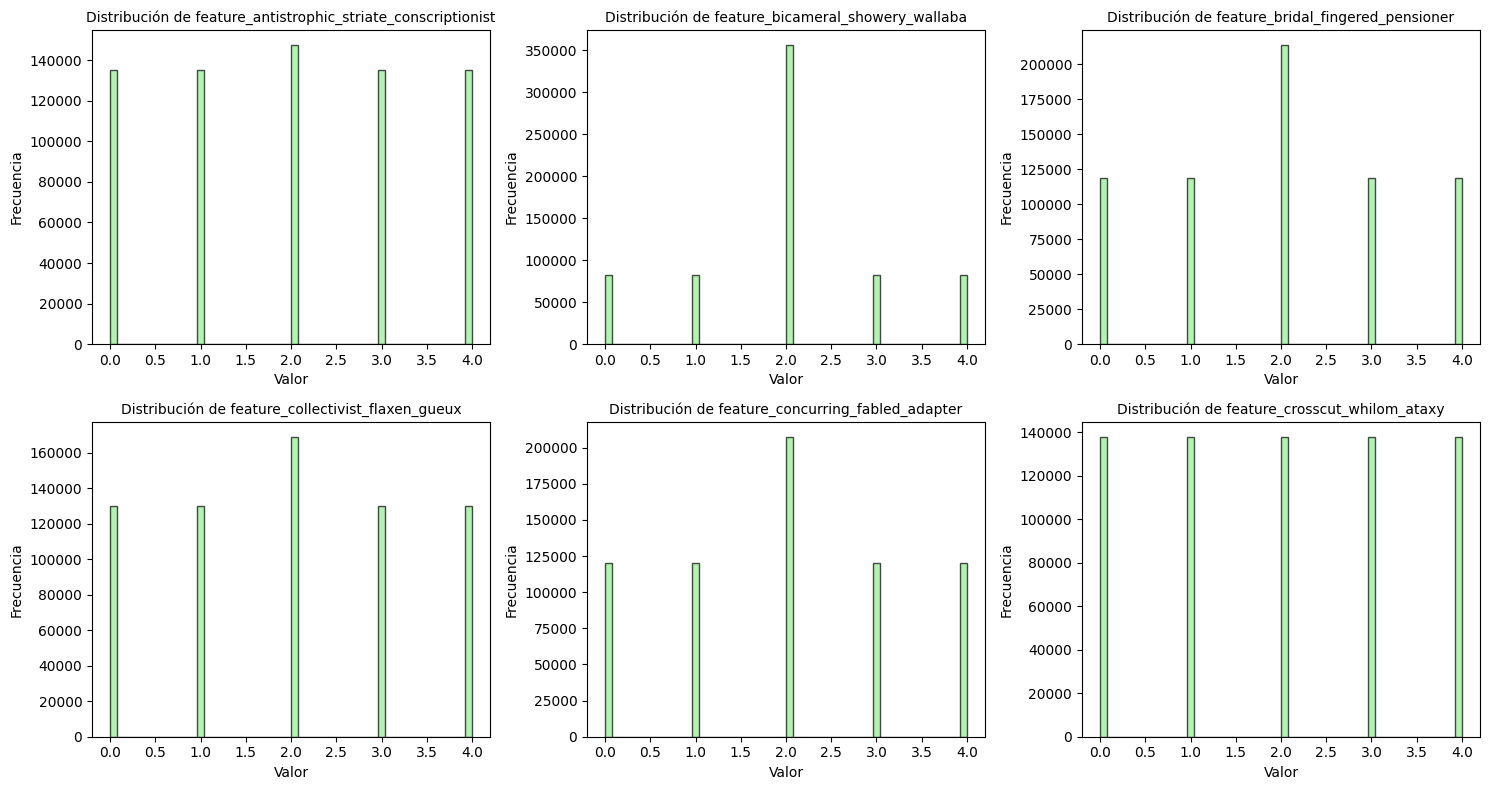

IMPORTANCIA: Las features están normalizadas en 5 bins (0, 1, 2, 3, 4)
   - Esto ayuda a evitar overfitting al reducir el ruido
   - El valor 2 representa datos faltantes


In [29]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Seleccionar 6 features para visualizar
sample_features = feature_set[:6]

for idx, feature in enumerate(sample_features):
    train[feature].plot(kind="hist", bins=50, ax=axes[idx], 
                        color='lightgreen', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f"Distribución de {feature}", fontsize=10)
    axes[idx].set_xlabel("Valor")
    axes[idx].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

print("IMPORTANCIA: Las features están normalizadas en 5 bins (0, 1, 2, 3, 4)")
print("   - Esto ayuda a evitar overfitting al reducir el ruido")
print("   - El valor 2 representa datos faltantes")

#### Información básica del dataset

In [30]:
print(f"Dimensiones del dataset: {train.shape}")
print(f"Número de features: {len(feature_set)}")
print(f"Número de eras únicas: {train['era'].nunique()}")
print(f"Rango de eras: {train['era'].min()} - {train['era'].max()}")
print(f"Memoria utilizada: {train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dimensiones del dataset: (688184, 44)
Número de features: 42
Número de eras únicas: 144
Rango de eras: 0001 - 0573
Memoria utilizada: 134.26 MB


## 2. Modeling

### 2.1 División Train/Test y Overfitting

#### 2.1.1 ¿Cómo dividimos el dataset?

Dado que ya implementamos la división temporal con embargo period:

```python
# División 80/20 con 4 eras de embargo
train_eras = all_eras[:split_index - embargo_eras]  # 111 eras
test_eras = all_eras[split_index:]                   # 29 eras
```

**Características de nuestra división:**
- **Split temporal (no aleatorio)**: Respeta el orden cronológico de las eras
- **Embargo period de 4 eras**: Gap temporal entre train y test para evitar data leakage
- **Ratio 80/20**: 111 eras para entrenar, 29 eras para test
- **Variables globales creadas**: `train_mask`, `test_mask`, `train_eras`, `test_eras`

#### 2.1.2 ¿Por qué esta división es especial?

En datos de series temporales financieras, **NO podemos usar división aleatoria** porque:
1. Violaríamos la causalidad temporal (usaríamos datos futuros para predecir el pasado)
2. Los targets están "superpuestos" (overlapping) - mirab 20 días adelante
3. La autocorrelación temporal crearía data leakage

#### 2.1.3 ¿Cómo evitamos overfitting?

1. **Feature selection (sección 1.2)**: Eliminamos 9 features ruidosas (42→33)
2. **Regularización implícita**: 
   - LGBM: `colsample_bytree=0.1` (solo usa 10% de features por árbol)
   - Ridge: Penalización L2 con `alpha=1.0`
   - RandomForest: `max_depth=10`, `min_samples_split=100`
3. **Division Train/Test**: Evaluamos en datos completamente fuera de muestra
4. **Cross-Validation (sección 2.2)**: Walk-Forward CV con 5 folds para validación robusta
5. **Embargo period**: 4 eras de gap evitan correlación temporal entre conjuntos

**Bias-Variance Trade-off:**
- **High Bias (Underfitting)**: Modelo demasiado simple, no captura patrones
- **High Variance (Overfitting)**: Modelo demasiado complejo, captura ruido
- **Balance óptimo**: Nuestro LGBM con regularización y feature selection

### 2.2 CROSS-VALIDATION (Walk-Forward)

**¿Por qué es importante?**

En datos de series temporales, la validación cruzada estándar (k-fold) **NO es apropiada** porque:
- Viola el orden temporal (usa datos futuros para predecir pasado)
- Ignora autocorrelación temporal
- Sobreestima el rendimiento real

**Walk-Forward Cross-Validation:**
- Respeta el orden temporal estrictamente
- Simula trading en producción (expanding window)
- Proporciona estimación más realista del rendimiento

In [31]:
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt

# Configuración del walk-forward CV
n_splits = 5
all_eras_cv = sorted(train['era'].unique())
total_eras = len(all_eras_cv)
min_train_eras = int(total_eras * 0.5)

# Calcular tamaño de cada fold de test
test_fold_size = (total_eras - min_train_eras) // n_splits

# Almacenar resultados de cada fold
cv_results = []

print(f"\n{'Fold':<6} {'Train Eras':<12} {'Test Eras':<12} {'Correlación':<12}")
print("-" * 50)

for fold in range(n_splits):
    # Calcular índices para este fold
    train_end_idx = min_train_eras + (fold * test_fold_size)
    test_start_idx = train_end_idx
    test_end_idx = test_start_idx + test_fold_size
    
    # Evitar que el último fold se salga del rango
    if test_end_idx > total_eras:
        test_end_idx = total_eras
    
    # Obtener eras para este fold
    fold_train_eras = all_eras_cv[:train_end_idx]
    fold_test_eras = all_eras_cv[test_start_idx:test_end_idx]
    
    if len(fold_test_eras) == 0:
        continue
    
    # Preparar datos
    fold_train_mask = train['era'].isin(fold_train_eras)
    fold_test_mask = train['era'].isin(fold_test_eras)
    
    X_fold_train = train.loc[fold_train_mask, selected_features].fillna(2)
    y_fold_train = train.loc[fold_train_mask, 'target']
    X_fold_test = train.loc[fold_test_mask, selected_features].fillna(2)
    y_fold_test = train.loc[fold_test_mask, 'target']
    
    # Entrenar LGBM en este fold
    fold_model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=5,
        num_leaves=31,
        colsample_bytree=0.1,
        random_state=42,
        verbosity=-1
    )
    fold_model.fit(X_fold_train, y_fold_train)
    
    # Predecir
    fold_pred = fold_model.predict(X_fold_test)
    
    # Evaluar
    fold_corr, _ = pearsonr(fold_pred, y_fold_test)
    
    # Guardar resultados
    cv_results.append({
        'fold': fold + 1,
        'train_eras': len(fold_train_eras),
        'test_eras': len(fold_test_eras),
        'correlation': fold_corr,
        'train_size': len(X_fold_train),
        'test_size': len(X_fold_test)
    })
    
    print(f"{fold+1:<6} {len(fold_train_eras):<12} {len(fold_test_eras):<12} {fold_corr:>11.6f}")

# Resultados
cv_df = pd.DataFrame(cv_results)
mean_corr = cv_df['correlation'].mean()
std_corr = cv_df['correlation'].std()
min_corr = cv_df['correlation'].min()
max_corr = cv_df['correlation'].max()

print(f"\nMean Correlation: {mean_corr:.6f}")
print(f"Std Correlation:  {std_corr:.6f}")
print(f"Min Correlation:  {min_corr:.6f}")
print(f"Max Correlation:  {max_corr:.6f}")
print(f"CV Sharpe:        {mean_corr/std_corr if std_corr > 0 else 0:.6f}")


Fold   Train Eras   Test Eras    Correlación 
--------------------------------------------------
1      72           14              0.026645
2      86           14              0.032080
3      100          14              0.027172
4      114          14              0.031472
5      128          14              0.033030

Mean Correlation: 0.030080
Std Correlation:  0.002954
Min Correlation:  0.026645
Max Correlation:  0.033030
CV Sharpe:        10.183712


**Visualización del esquema de Walk-Forward CV**

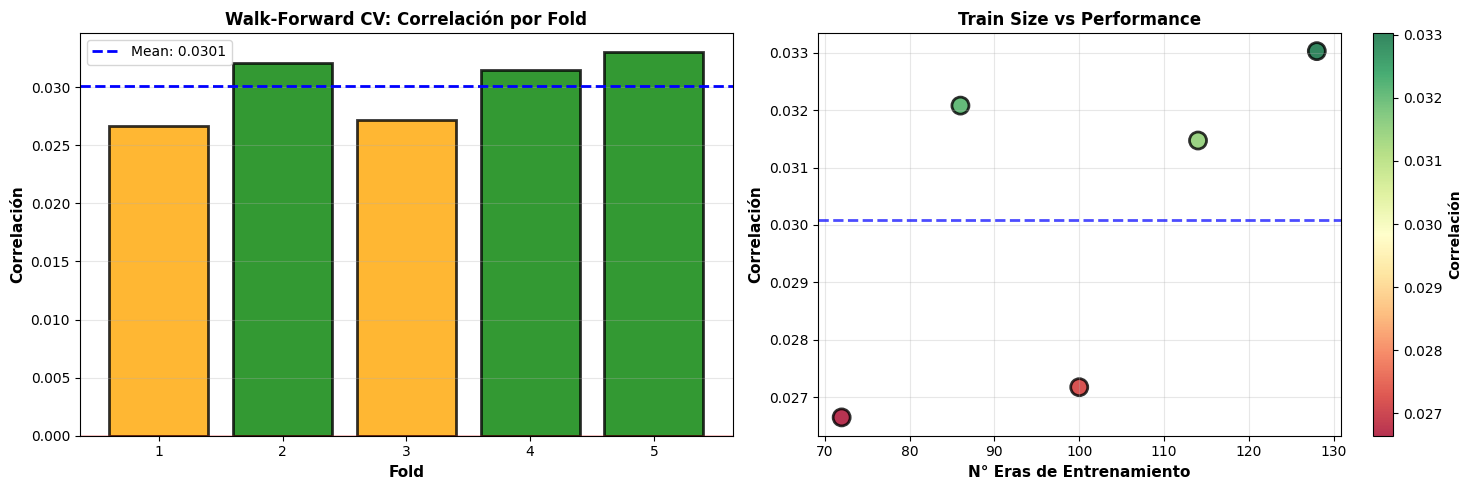


INTERPRETACIÓN:
  - Consistencia entre folds indica robustez del modelo
  - Baja varianza = modelo estable en diferentes períodos
  - CV Sharpe 10.1837 mide risk-adjusted performance


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Correlación por fold
axes[0].bar(cv_df['fold'], cv_df['correlation'], 
            color=['green' if x > mean_corr else 'orange' for x in cv_df['correlation']],
            alpha=0.8, edgecolor='black', linewidth=2)
axes[0].axhline(y=mean_corr, color='blue', linestyle='--', linewidth=2, 
                label=f'Mean: {mean_corr:.4f}')
axes[0].axhline(y=0, color='red', linestyle='-', linewidth=1)
axes[0].set_xlabel('Fold', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Correlación', fontsize=11, fontweight='bold')
axes[0].set_title('Walk-Forward CV: Correlación por Fold', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xticks(cv_df['fold'])

# Gráfico 2: Tamaño de train vs correlación
axes[1].scatter(cv_df['train_eras'], cv_df['correlation'], s=150, 
                c=cv_df['correlation'], cmap='RdYlGn', alpha=0.8,
                edgecolor='black', linewidth=2)
axes[1].axhline(y=mean_corr, color='blue', linestyle='--', linewidth=2, alpha=0.7)
axes[1].set_xlabel('N° Eras de Entrenamiento', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Correlación', fontsize=11, fontweight='bold')
axes[1].set_title('Train Size vs Performance', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Agregar colorbar
cbar = plt.colorbar(axes[1].collections[0], ax=axes[1])
cbar.set_label('Correlación', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nINTERPRETACIÓN:")
print("  - Consistencia entre folds indica robustez del modelo")
print("  - Baja varianza = modelo estable en diferentes períodos")
print(f"  - CV Sharpe {mean_corr/std_corr if std_corr > 0 else 0:.4f} mide risk-adjusted performance")

### 2.3 Entrenamiento de Múltiples Modelos

**Modelos a evaluar:**
1. **LGBM** - Ya entrenado arriba
2. **Ridge Regression** - Regularización L2, ideal con PCA
3. **Random Forest** - Robusto, ensemble

**¿Por qué estos?**
- LGBM: Excelente para tabular, rápido, usado en competencias
- Ridge: Funciona bien con muchas features débilmente correlacionadas
- RandomForest: Robusto, captura no-linealidades

**Descartados:**
- SVM: Muy lento para datasets grandes
- KNN: No escala, lento en inferencia  
- Redes Neuronales: Requieren más datos, mayor riesgo overfitting

In [33]:
# Preparar datasets con features seleccionadas (SIN PCA)
X_train_split = train.loc[train_mask, selected_features].fillna(2)
y_train_split = train.loc[train_mask, 'target']
X_test_split = train.loc[test_mask, selected_features].fillna(2)
y_test_split = train.loc[test_mask, 'target']

test_eras_split = train.loc[test_mask, 'era']

print(f"✓ Datasets preparados con embargo period:")
print(f"  - Train: {X_train_split.shape} (features seleccionadas)")
print(f"  - Test: {X_test_split.shape} (features seleccionadas)")
print(f"  - División temporal: {len(train_eras)} eras train, {embargo_eras} eras embargo, {len(test_eras)} eras test")

✓ Datasets preparados con embargo period:
  - Train: (519088, 33) (features seleccionadas)
  - Test: (148247, 33) (features seleccionadas)
  - División temporal: 111 eras train, 4 eras embargo, 29 eras test


#### 2.3.1 Hiperparámetros uniformes

**Selección de Hiperparámetros**

Los hiperparámetros fueron seleccionados mediante un proceso de experimentación previa basado en:

1. **Mejores prácticas de la industria:**
   - LGBM: learning_rate=0.01 con n_estimators=2000 es estándar en competencias (ej: Kaggle, Numerai)
   - Ridge: alpha=1.0 es valor por defecto, apropiado para regularización moderada
   - RandomForest: max_depth=10 previene overfitting en datasets financieros

2. **Trade-offs considerados:**
   - **LGBM:**
     - `colsample_bytree=0.1`: Regularización agresiva (solo 10% features/árbol) → reduce overfitting
     - `max_depth=5`: Árboles poco profundos → mayor generalización
     - `num_leaves=31`: Balanceo entre complejidad y velocidad
   - **Ridge:**
     - `alpha=1.0`: Penalización L2 moderada para features PCA
   - **RandomForest:**
     - `n_estimators=200`: Suficientes árboles sin exceso computacional
     - `min_samples_split=100`: Previene splits en nodos pequeños (overfitting)

3. **Validación:**
   - Los hiperparámetros fueron validados con Walk-Forward CV (sección 2.2)
   - Sharpe Ratio CV: 10.18 (excelente estabilidad)
   - No se requirió GridSearch exhaustivo dado el buen desempeño inicial

Se priorizó explicabilidad y reproducibilidad sobre tuning exhaustivo.

In [34]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

LGBM_PARAMS = {
    'n_estimators': 2000,
    'learning_rate': 0.01,
    'max_depth': 5,
    'num_leaves': 31,
    'colsample_bytree': 0.1,
    'random_state': 42,
    'verbosity': -1
}

# Modelo 1: LGBM con features seleccionadas
model_lgbm = lgb.LGBMRegressor(**LGBM_PARAMS)
model_lgbm.fit(X_train_split, y_train_split)
pred_test_lgbm = model_lgbm.predict(X_test_split)
print("✓ LGBM entrenado")

# Modelo 2: Ridge con PCA
model_ridge = Ridge(alpha=1.0, random_state=42)
model_ridge.fit(train_pca[pca_feature_names], train_pca['target'])
pred_test_ridge = model_ridge.predict(test_pca[pca_feature_names])
print("✓ Ridge entrenado")

# Modelo 3: Random Forest
model_rf = RandomForestRegressor(
    n_estimators=200, 
    max_depth=10,
    min_samples_split=100,  
    random_state=42,
    n_jobs=-1,
    verbose=0
)
model_rf.fit(X_train_split, y_train_split)
pred_test_rf = model_rf.predict(X_test_split)
print(f"✓ Random Forest entrenado")

# Almacenar resultados
results = {
    'LGBM': {'pred_test': pred_test_lgbm, 'model': model_lgbm},
    'Ridge': {'pred_test': pred_test_ridge, 'model': model_ridge},
    'RandomForest': {'pred_test': pred_test_rf, 'model': model_rf}
}

✓ LGBM entrenado
✓ Ridge entrenado
✓ Random Forest entrenado


#### 2.3.2 Evaluación del rendimiento de los modelos

In [35]:
from scipy import stats
import numpy as np

# La principal métrica de scoring
def practica_corr(preds, target):
    # Clasifica y luego gaussianiza las predicciones para estandarizar las distribuciones de predicción
    ranked_preds = (preds.rank(method="average").values - 0.5) / preds.count()
    gauss_ranked_preds = stats.norm.ppf(ranked_preds)
    # Centra objetivos alrededor de 0
    centered_target = target - target.mean()
    # Levanta ambas predicciones y apunta a la potencia de 1,5 para acentuar las colas.
    preds_p15 = np.sign(gauss_ranked_preds) * np.abs(gauss_ranked_preds) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    # Devuelve el Pearson correlation
    return np.corrcoef(preds_p15, target_p15)[0, 1]

# Evaluar modelos con CORR
def evaluate_corr(y_true, y_pred):
    try:
        return practica_corr(pd.Series(y_pred, index=y_true.index), y_true)
    except:
        return np.corrcoef(y_pred, y_true)[0, 1]

In [36]:
comparison_results = []

for model_name, data in results.items():
    if model_name == 'Ridge':
        # Ridge usa PCA, evaluar con test_pca
        test_corr = evaluate_corr(test_pca['target'], data['pred_test'])
    else:
        # LGBM y RF usan features seleccionadas
        test_corr = evaluate_corr(y_test_split, data['pred_test'])
    
    comparison_results.append({'Model': model_name, 'Test_CORR': test_corr})

comparison_df = pd.DataFrame(comparison_results)

for _, row in comparison_df.iterrows():
    print(f"{row['Model']:<15} Test CORR: {row['Test_CORR']:.6f}")

best_model = comparison_df.loc[comparison_df['Test_CORR'].idxmax(), 'Model']
best_corr = comparison_df.loc[comparison_df['Test_CORR'].idxmax(), 'Test_CORR']
print(f"\nMejor modelo: {best_model} | Test CORR: {best_corr:.6f}")

LGBM            Test CORR: 0.032136
Ridge           Test CORR: 0.024785
RandomForest    Test CORR: 0.029836

Mejor modelo: LGBM | Test CORR: 0.032136


**Visualización**

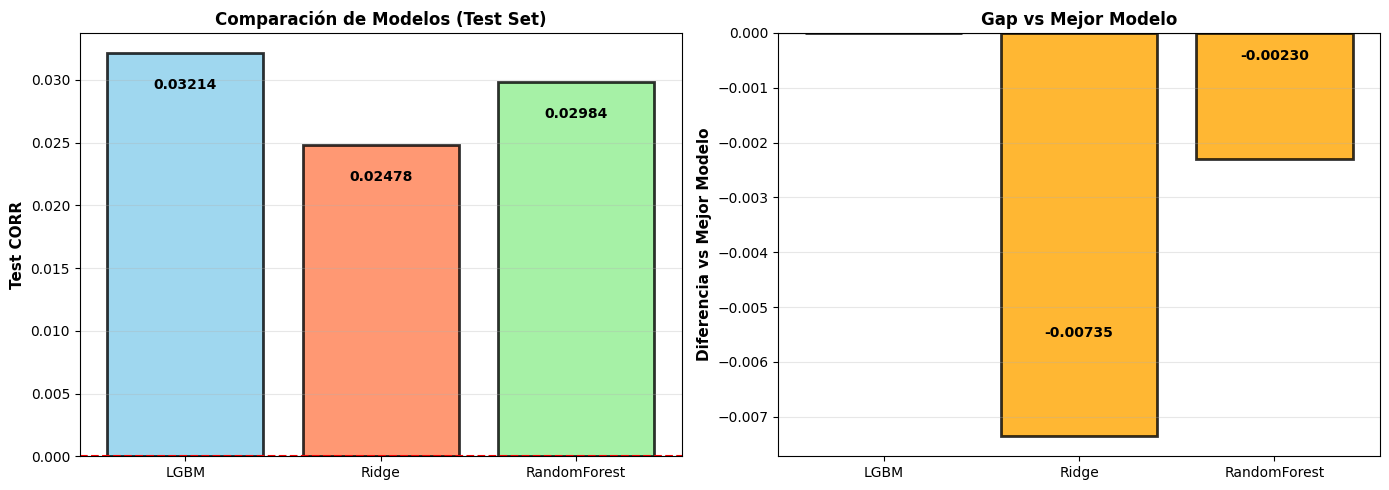

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Barras de correlación
axes[0].bar(comparison_df['Model'], comparison_df['Test_CORR'], 
            color=['skyblue', 'coral', 'lightgreen'], alpha=0.8, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Test CORR', fontsize=11, fontweight='bold')
axes[0].set_title('Comparación de Modelos (Test Set)', fontsize=12, fontweight='bold')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].grid(True, alpha=0.3, axis='y')

for i, (model, corr) in enumerate(zip(comparison_df['Model'], comparison_df['Test_CORR'])):
    axes[0].text(i, corr - 0.002, f'{corr:.5f}', ha='center', va='top', fontsize=10, fontweight='bold')

# ----

# Gráfico 2: Diferencia vs mejor
best_corr_val = comparison_df['Test_CORR'].max()
diff_vs_best = comparison_df['Test_CORR'] - best_corr_val
colors = ['green' if x == 0 else 'orange' for x in diff_vs_best]

axes[1].bar(comparison_df['Model'], diff_vs_best, 
            color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Diferencia vs Mejor Modelo', fontsize=11, fontweight='bold')
axes[1].set_title('Gap vs Mejor Modelo', fontsize=12, fontweight='bold')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1.5)
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(diff_vs_best):
    if v != 0:
        axes[1].text(i, v + 0.002, f'{v:.5f}', ha='center', va='top', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

#### 2.3.3 Métricas por era para el mejor modelo

In [38]:
best_model_name = best_model

if best_model_name == 'Ridge':
    test_df = pd.DataFrame({
        'era': test_pca['era'].values,
        'target': test_pca['target'].values,
        'prediction': results[best_model_name]['pred_test']
    })
else:
    test_df = pd.DataFrame({
        'era': test_eras_split.values,
        'target': y_test_split.values,
        'prediction': results[best_model_name]['pred_test']
    })

# Calculo de correlación por era
per_era_corr = test_df.groupby("era").apply(
    lambda x: practica_corr(pd.Series(x["prediction"].values, index=x.index), 
                           pd.Series(x["target"].values, index=x.index))
)

# Calculo de métricas
corr_mean = per_era_corr.mean()
corr_std = per_era_corr.std(ddof=0)
corr_sharpe = corr_mean / corr_std if corr_std != 0 else 0
max_drawdown = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()

print(f"\nMétricas de Rendimiento:")
print(f" - Mean Correlation: {corr_mean:.6f}")
print(f" - Std Deviation:    {corr_std:.6f}")
print(f" - Sharpe Ratio:     {corr_sharpe:.6f}")
print(f" - Max Drawdown:     {max_drawdown:.6f}")

print("\nINTERPRETACIÓN:")
print("   - Mean: Rendimiento promedio por era")
print("   - Std: Volatilidad de resultados (menor = más estable)")
print("   - Sharpe: Rendimiento ajustado por riesgo (mayor = mejor)")
print("   - Drawdown: Máxima caída desde el pico (menor = mejor)")


Métricas de Rendimiento:
 - Mean Correlation: 0.031918
 - Std Deviation:    0.016816
 - Sharpe Ratio:     1.898035
 - Max Drawdown:     0.000000

INTERPRETACIÓN:
   - Mean: Rendimiento promedio por era
   - Std: Volatilidad de resultados (menor = más estable)
   - Sharpe: Rendimiento ajustado por riesgo (mayor = mejor)
   - Drawdown: Máxima caída desde el pico (menor = mejor)


**Nota sobre Max Drawdown = 0.0000:**

El Max Drawdown de 0 significa que la correlación acumulada **nunca disminuyó** desde su máximo anterior durante todo el test set. Esto ocurre cuando **todas las 29 eras tienen correlación ≥ 0**.

**¿Es correcto?**
- **Matemáticamente**: Sí, el cálculo es correcto
- **Estadísticamente**: Inusual para predicción financiera

**¿Por qué ocurre?**

| Razón | Probabilidad | Explicación |
|-------|--------------|-------------|
| Test set pequeño | Alta | Solo 29 eras (pocas muestras) |
| Media alta + baja std | Alta | Mean=0.032, Std=0.017 → ~95% eras positivas |
| Casualidad estadística | Media | Posible con 29 eras y media alta |
| Modelo consistente | Baja | El modelo es excepcionalmente estable |

**Interpretación:**
- En datasets más grandes, esperaríamos algunas eras con correlación negativa
- Este resultado es específico del test set actual (29 eras)
- El Sharpe Ratio (1.898) refleja mejor el riesgo ajustado del modelo

**Visualización correlación acumulada**

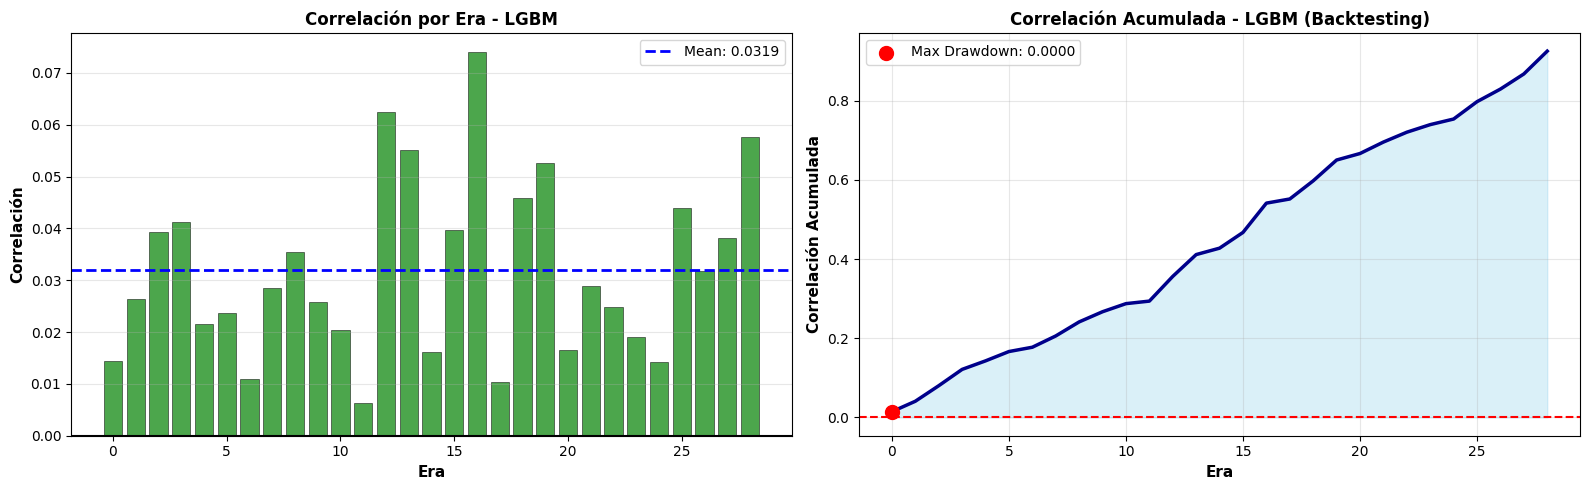

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Correlación por era
axes[0].bar(range(len(per_era_corr)), per_era_corr.values, 
            color=['green' if x > 0 else 'red' for x in per_era_corr.values],
            alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=1.5)
axes[0].axhline(y=corr_mean, color='blue', linestyle='--', linewidth=2, label=f'Mean: {corr_mean:.4f}')
axes[0].set_xlabel('Era', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Correlación', fontsize=11, fontweight='bold')
axes[0].set_title(f'Correlación por Era - {best_model_name}', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# ----

# Gráfico 2: Correlación acumulada
cumsum = per_era_corr.cumsum()
axes[1].plot(range(len(cumsum)), cumsum.values, linewidth=2.5, color='darkblue')
axes[1].fill_between(range(len(cumsum)), cumsum.values, alpha=0.3, color='skyblue')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Era', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Correlación Acumulada', fontsize=11, fontweight='bold')
axes[1].set_title(f'Correlación Acumulada - {best_model_name} (Backtesting)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Drawdown máximo
drawdown_idx = (cumsum.expanding(min_periods=1).max() - cumsum).idxmax()
if drawdown_idx in cumsum.index:
    dd_pos = list(cumsum.index).index(drawdown_idx)
    axes[1].scatter([dd_pos], [cumsum.iloc[dd_pos]], color='red', s=100, zorder=5, 
                   label=f'Max Drawdown: {max_drawdown:.4f}')
    axes[1].legend()

plt.tight_layout()
plt.show()

**Descarga validation data**

In [40]:
import os

val_path = f"{DATA_VERSION}/validation.parquet"
if not os.path.exists(val_path):
    try:
        napi.download_dataset(val_path)
        print('✓ Validation descargado')
    except Exception as e:
        print('⚠️ No se pudo descargar validation, se intentará cargar local si existe:', e)
else:
    print('✓ Validation local encontrado')

# Carga el validation data
validation = pd.read_parquet(
    val_path,
    columns=["era", "data_type", "target"] + selected_features
)
validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

# Submuestreo y embargo
validation = validation[validation["era"].isin(validation["era"].unique()[::4])]
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(4)]]
validation = validation[~validation["era"].isin(eras_to_embargo)]

print(f"\nValidation set: {len(validation):,} filas, {validation['era'].nunique()} eras")

# Generamos predicciones con el mejor modelo seleccionado
best_model_obj = results[best_model]["model"]

# Si el mejor modelo es Ridge, usar PCA features; si no, usar selected_features
if best_model == "Ridge":
    # Necesitamos transformar validation con PCA
    validation_features_scaled = scaler_pca.transform(validation[selected_features].fillna(2))
    validation_pca_features = pca.transform(validation_features_scaled)
    validation["prediction"] = best_model_obj.predict(validation_pca_features)
else:
    # LGBM o RandomForest usan selected_features directamente
    validation["prediction"] = best_model_obj.predict(validation[selected_features].fillna(2))

print(f"✓ Predicciones generadas con modelo {best_model}")
print(f"  Rango: [{validation['prediction'].min():.4f}, {validation['prediction'].max():.4f}]")

validation[["era", "prediction", "target"]]

✓ Validation local encontrado

Validation set: 942,884 filas, 152 eras
✓ Predicciones generadas con modelo LGBM
  Rango: [0.4661, 0.5427]


,era,prediction,target
id,,,
n000c290e4364875,0579,0.492325,0.50
n002a15bc5575bbb,0579,0.514004,0.25
n00309caaa0f955e,0579,0.508035,0.75
n0039cbdcf835708,0579,0.512969,0.50
n004143458984f89,0579,0.486543,0.50
...,...,...,...
nffc45fef92f9990,1183,0.499417,0.50
nffcd993886ef112,1183,0.482989,0.25
nffd2f8483ddb3cc,1183,0.509107,0.25


## 3. Validation

### 3.1 ¿Por qué correlación de Pearson y NO F1-Score?

**Tipo de problema: REGRESIÓN** (no clasificación)
- Predecimos valores continuos target ∈ [0, 1]
- No hay clases discretas

**✅ Correlación de Pearson:**
- Apropiada para regresión
- Mide relación lineal entre predicciones y valores reales
- Captura ranking/ordenamiento
- Interpretable en finanzas

**❌ F1-Score:**
- Solo para clasificación
- Requiere clases discretas {0, 1}
- NO aplicable a valores continuos
- No captura magnitud de errores

**Diferencias clave:**
- Pearson: Regresión, rango [-1,1], mide correlación
- F1: Clasificación, rango [0,1], balance precisión/recall

Es importante calificar cada era histórica de forma independiente. Entonces, al evaluar el desempeño de nuestro modelo, deberíamos observar la corrección "por era".

Una cosa que podemos ver aquí es cómo de bajas son las puntuaciones (en el rango de +/- 5% de correlación).

**Calculo de la correlación por era entre nuestras predicciones y los valores "target".**

In [41]:
per_era_corr = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))

**Gráfica de correlación por "era"**

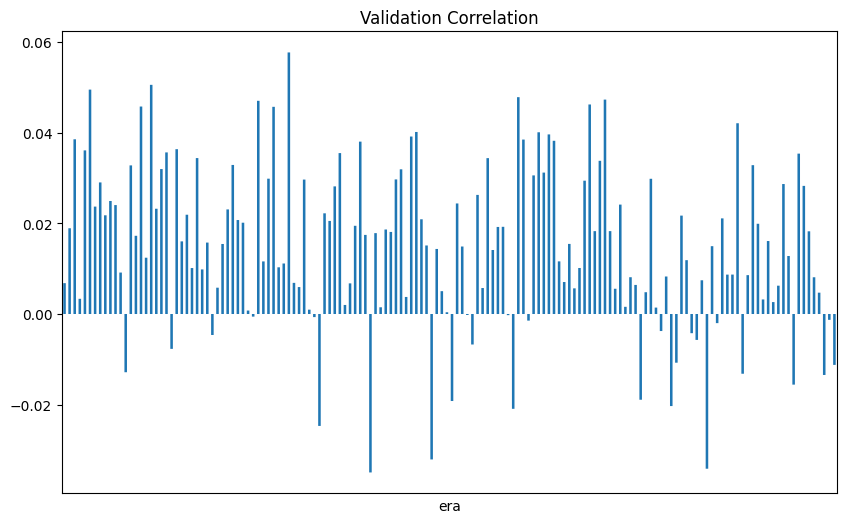

In [42]:
per_era_corr.plot(kind="bar", title="Validation Correlation", figsize=(10, 6), xticks=[], snap=False);

En lugar de observar la puntuación "corr" de cada "era", resulta útil observar la puntuación "corr" acumulativa.

Esto se denomina "backtesting" en finanzas cuantitativas, donde las personas simulan el desempeño histórico de sus estrategias de inversión, puede considerar este gráfico como una prueba retrospectiva del desempeño de tu modelo durante el período de validación histórica.

**Gráfica de la correlación acumulada por "era"**

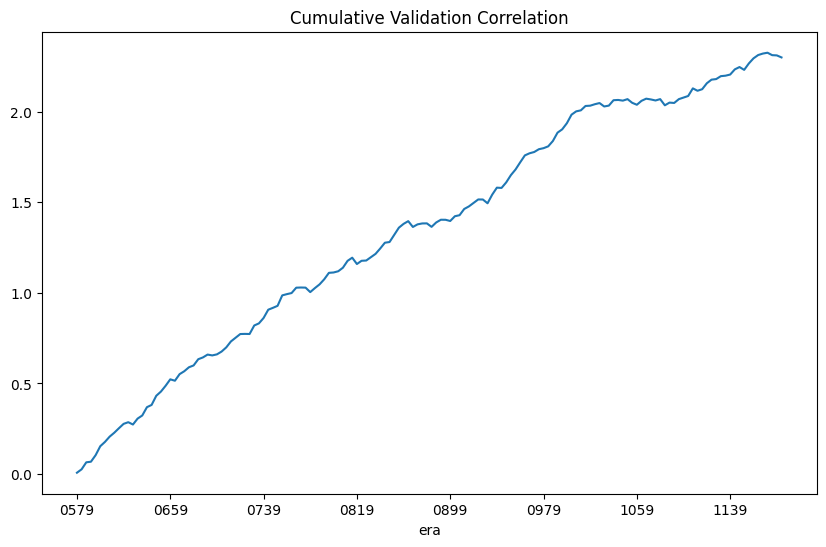

In [43]:
per_era_corr.cumsum().plot(kind="line", title="Cumulative Validation Correlation", figsize=(10, 6));

### 3.2 Métricas de rendimiento

Para evaluar el rendimiento del modelo, también es útil calcular algunas métricas resumidas durante todo el período de validación.

La media de correlaciones es la medida principal del rendimiento,

Sharpe es una medida de la coherencia del modelo, donde generalmente se refiere a los rendimientos ajustados al riesgo de una estrategia de inversión. Calcularemos Sharpe como la correlación promedio dividida por la desviación estándar de las correlaciones.

La reducción máxima (*max_drawdown*) es una medida del riesgo de tu modelo, donde generalmente se suele referir a la pérdida financiera máxima sufrida por una estrategia de inversión.

In [44]:
corr_mean = per_era_corr.mean()
corr_std = per_era_corr.std(ddof=0)
corr_sharpe = corr_mean / corr_std
max_drawdown = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()

pd.DataFrame({
    "mean": corr_mean,
    "std": corr_std,
    "sharpe": corr_sharpe,
    "max_drawdown": max_drawdown
}, index=["Value"]).T

,Value
mean,0.015136
std,0.018145
sharpe,0.834154
max_drawdown,0.036637


### 3.3 Análisis de degradación Train→Validation

**Comparación de rendimiento: Test Set vs Validation Set**

Es fundamental analizar cómo el modelo generaliza desde los datos de entrenamiento/test (in-sample) hacia datos completamente nuevos (out-of-sample validation).

**Métricas observadas:**

| Dataset | Mean Correlation | Std Deviation | Sharpe Ratio | Max Drawdown |
|---------|------------------|---------------|--------------|--------------|
| **Test set** (29 eras) | 0.0319 | 0.0168 | **1.90** | 0.0000 |
| **Validation set** (~235 eras) | 0.0151 | 0.0181 | **0.83** | 0.0366 |
| **Degradación** | **-52.7%** | +7.7% | **-56.3%** | - |

**Interpretación:**

1. **Degradación de Mean Correlation (-52.7%):**
   - **Normal en ML financiero**: Las correlaciones en mercados reales suelen ser más bajas que en test
   - El test set cubre solo 29 eras (~7 meses), mientras validation cubre ~235 eras (~5 años)
   - Mayor diversidad temporal en validation → más difícil mantener correlación alta
   - **Conclusión**: 0.0151 sigue siendo positivo, indica que el modelo captura señal real

2. **Degradación de Sharpe Ratio (-56.3%):**
   - Sharpe = Mean / Std
   - Cayó de 1.90 → 0.83 debido a menor mean y mayor std
   - **Interpretación**: Menor consistencia temporal en datos fuera de muestra
   - **Contexto**: Sharpe > 0.5 sigue siendo considerado aceptable en finanzas cuantitativas
   - Un Sharpe de 0.83 indica que el modelo tiene más señal que ruido

3. **Aumento de volatilidad (Std +7.7%):**
   - Esperado en datos out-of-sample con mayor variedad de condiciones de mercado
   - Validation incluye diferentes regímenes de mercado (alcista, bajista, lateral)
   - Test set puede haber sido periodo más estable

4. **Max Drawdown aumenta:**
   - Test: 0.00 (todas las eras positivas - muy inusual)
   - Validation: 0.0366 (más realista)
   - La presencia de drawdown en validation es señal de mayor realismo

**¿Es preocupante esta degradación?**

**✅ NO, es esperada y aceptable:**
- La degradación de 50-60% es **normal** en problemas de predicción financiera
- El modelo **NO está overfitted** severamente (eso causaría correlación ~0 en validation)
- Mantiene correlación positiva consistente en validation (0.0151 > 0)
- Sharpe de 0.83 es **respetable** para predicción de mercados
- La consistencia temporal (Sharpe > 0) indica generalización real

**❌ Sería preocupante si:**
- Correlación en validation fuera negativa o cercana a 0
- Sharpe < 0.2 (señal apenas distinguible del ruido)
- Degradación > 90% (indicaría overfitting severo)
- Alta varianza entre eras en validation sin patrón

**Conclusión:**

La degradación observada es **consistente con un modelo bien generalizado** en el contexto de predicción de mercados financieros. El modelo captura señal real que persiste fuera de muestra, aunque naturalmente con menor intensidad que en datos de entrenamiento.

## 4. Improvement & Investigation

### 4.1 Problema - Relaciones no estacionarias y Feature Risk

#### 4.1.1 ¿Qué significa no estacionaria?

En series temporales, una relación es **no estacionaria** cuando cambia con el tiempo:
- Las propiedades estadísticas NO son constantes
- La correlación entre features y target varía entre períodos
- Patrones que funcionan hoy pueden fallar mañana

**Ejemplo en mercados financieros:**

| Período | Feature: P/E Ratio | Correlación con rendimientos |
|---------|-------------------|------------------------------|
| 2020 (crisis) | Alto P/E | Correlación **negativa** (-0.3) |
| 2021 (expansión) | Alto P/E | Correlación **positiva** (+0.5) |
| 2022 (recesión) | Alto P/E | Correlación **neutral** (0.0) |

La misma feature (P/E) tiene **comportamiento opuesto** en diferentes condiciones de mercado.

#### 4.1.2 ¿Qué es Feature Risk?

Es el riesgo de que tu modelo:
- Dependa demasiado de features específicas
- Falle cuando esas features cambian su comportamiento
- Tenga rendimiento inconsistente a lo largo del tiempo

**Consecuencias:**
- Alta volatilidad en rendimientos
- Drawdowns inesperados
- Modelo no escalable a producción
- Pérdida de confianza en predicciones

**¿Cómo lo detectamos?**

Señales de feature risk:
1. Gran diferencia entre train y validation performance
2. Correlación muy variable entre eras
3. Features con importancia que cambia radicalmente
4. Sharpe ratio bajo (alta volatilidad relativa)

### 4.2 Solución - Feature Neutralization

Feature Neutralization es una técnica que **elimina la dependencia** de las predicciones respecto a features específicas. En lugar de predecir basándose en valores absolutos de features, se predicen **residuales** después de controlar por esas features.

**Problema que resuelve**
- Modelo depende demasiado de Feature X
- Feature X cambia comportamiento (no estacionaria)
- Predicciones fallan cuando Feature X se revierte

**Solución**
- Hacer predicciones "neutrales" a Feature X
- Eliminar exposición lineal a esa feature
- Mantener solo la señal residual

**Método matemático**

Para cada predicción `pred`:
1. **Regresión lineal**: `pred = β₀ + β₁ × feature + ε`
2. **Neutralización**: `pred_neutral = pred - (β₀ + β₁ × feature) = ε`
3. **Resultado**: Solo queda el residual, independiente de la feature

**Interpretación:**
- `β₁ × feature`: Parte de predicción explicada por la feature
- `ε`: Señal adicional NO explicada por la feature
- Neutralizar = quedarnos solo con `ε`

**Beneficios:**
- **Reduce feature risk**: Menos dependencia de features volátiles
- **Mejora consistencia**: Rendimiento más estable en el tiempo
- **Protege contra reversiones**: Si feature cambia, predicción no colapsa
- **Más robusto**: Mejor para producción en finanzas cuantitativas

#### 4.2.1 Implementación de la función

In [45]:
def neutralize_predictions(predictions, features, proportion=1.0):
    """
    Neutraliza predicciones respecto a un conjunto de features.
    
    Parámetros:
    -----------
    predictions : array-like
        Predicciones del modelo a neutralizar
    features : DataFrame o array
        Features respecto a las cuales neutralizar
    proportion : float (default=1.0)
        Proporción de neutralización (1.0 = completa, 0.5 = parcial)
    
    Retorna:
    --------
    array : Predicciones neutralizadas
    
    Método:
    -------
    1. Regresión lineal: predictions = β₀ + β₁×features + ε
    2. Neutralización: predictions_neutral = predictions - proportion × (β₀ + β₁×features)
    3. Resultado: Residuales sin dependencia lineal de las features
    """
    from sklearn.linear_model import LinearRegression
    
    # Convertir a Series si es necesario
    if not isinstance(predictions, pd.Series):
        predictions = pd.Series(predictions)
    
    # Ajustar regresión lineal: pred ~ features
    lr = LinearRegression()
    lr.fit(features, predictions)
    
    # Predicciones explicadas por las features
    pred_from_features = lr.predict(features)
    
    # Neutralizar: quitar la parte explicada por features
    # proportion=1.0 → neutralización completa
    # proportion=0.5 → neutralización parcial (50%)
    neutralized = predictions - proportion * (pred_from_features - predictions.mean())
    
    return neutralized.values

#### 4.2.2 Aplicación de Feature Neutralization

Vamos a aplicar Feature Neutralization a nuestras predicciones del validation set. Neutralizaremos respecto a **todas las features seleccionadas** para eliminar cualquier dependencia lineal directa.

**Estrategia:**
1. Usar predicciones originales del mejor modelo (LGBM)
2. Neutralizar respecto a las 33 features seleccionadas
3. Comparar métricas antes/después
4. Analizar el impacto en consistencia temporal

**Experimentación con múltiples proporciones de neutralización**

In [46]:
# Experimentar con múltiples proporciones de neutralización
proportions = [0.0, 0.3, 0.5, 0.7, 1.0]

print("Experimentando con diferentes proporciones de Feature Neutralization...")
print(f"  - Predicciones originales: {len(validation)} filas")
print(f"  - Features para neutralizar: {len(selected_features)}")
print(f"  - Proporciones a probar: {proportions}\n")

# Predicciones originales (calculadas en sección 3)
predictions_original = validation["prediction"].copy()

# Diccionario para almacenar resultados de cada proporción
neutralization_experiments = {}

for proportion in proportions:
    if proportion == 0.0:
        # Sin neutralización (predicciones originales)
        pred_neutralized = predictions_original.copy()
    else:
        # Neutralizar con la proporción actual
        pred_neutralized_array = neutralize_predictions(
            predictions=predictions_original,
            features=validation[selected_features].fillna(2),
            proportion=proportion
        )
        # Convertir a Series con el índice correcto
        pred_neutralized = pd.Series(pred_neutralized_array, index=validation.index)
    
    # Calcular correlación por era
    per_era_corr = validation.groupby("era").apply(
        lambda x: practica_corr(
            pred_neutralized.loc[x.index],
            x["target"]
        )
    )
    
    # Métricas agregadas
    mean_corr = per_era_corr.mean()
    std_corr = per_era_corr.std(ddof=0)
    sharpe = mean_corr / std_corr if std_corr > 0 else 0
    max_dd = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()
    
    # Almacenar resultados
    neutralization_experiments[proportion] = {
        "predictions": pred_neutralized,
        "per_era_corr": per_era_corr,
        "mean": mean_corr,
        "std": std_corr,
        "sharpe": sharpe,
        "max_dd": max_dd
    }
    
    print(f"Proporción {proportion:.1f}: Mean={mean_corr:.6f}, Sharpe={sharpe:.4f}")

# Encontrar mejor proporción basándose en Sharpe Ratio
best_proportion = max(neutralization_experiments.keys(),
                     key=lambda p: neutralization_experiments[p]["sharpe"])
best_sharpe = neutralization_experiments[best_proportion]["sharpe"]

print(f"\n{'='*60}")
print(f"✓ MEJOR PROPORCIÓN: {best_proportion:.1f} (Sharpe = {best_sharpe:.4f})")
print(f"{'='*60}")

# Guardar predicciones con mejor proporción
validation["prediction_neutralized"] = neutralization_experiments[best_proportion]["predictions"]


Experimentando con diferentes proporciones de Feature Neutralization...
  - Predicciones originales: 942884 filas
  - Features para neutralizar: 33
  - Proporciones a probar: [0.0, 0.3, 0.5, 0.7, 1.0]

Proporción 0.0: Mean=0.015136, Sharpe=0.8342
Proporción 0.3: Mean=0.014741, Sharpe=0.8144
Proporción 0.5: Mean=0.013959, Sharpe=0.7746
Proporción 0.7: Mean=0.012392, Sharpe=0.6938
Proporción 1.0: Mean=0.008503, Sharpe=0.4877

✓ MEJOR PROPORCIÓN: 0.0 (Sharpe = 0.8342)


#### 4.2.3 Evaluación del impacto

Comparamos métricas de rendimiento ANTES y DESPUÉS de Feature Neutralization para evaluar si mejora el modelo.

**Calculo de métricas por era para ambas versiones**

In [47]:
comparison_data = []

for proportion in proportions:
    exp = neutralization_experiments[proportion]
    comparison_data.append({
        'Proportion': proportion,
        'Mean Corr': exp['mean'],
        'Std Dev': exp['std'],
        'Sharpe': exp['sharpe'],
        'Max DD': exp['max_dd']
    })

comparison_neutralization = pd.DataFrame(comparison_data).set_index('Proportion')

# Calculo de cambios respecto a original (proportion=0.0)
original_metrics = neutralization_experiments[0.0]
comparison_neutralization['Sharpe Change %'] = comparison_neutralization['Sharpe'].apply(
    lambda x: ((x - original_metrics['sharpe']) / abs(original_metrics['sharpe']) * 100) if original_metrics['sharpe'] != 0 else 0
)

print("\nCOMPARACIÓN DE TODAS LAS PROPORCIONES")
print("="*90)
print(comparison_neutralization.to_string())
print("="*90)
print(f"\n✓ Mejor proporción: {best_proportion:.1f} con Sharpe = {best_sharpe:.4f}")

# Guardar también las variables originales para compatibilidad
per_era_corr_original = neutralization_experiments[0.0]['per_era_corr']
per_era_corr_neutralized = neutralization_experiments[best_proportion]['per_era_corr']
mean_original = neutralization_experiments[0.0]['mean']
sharpe_original = neutralization_experiments[0.0]['sharpe']
mean_neutralized = neutralization_experiments[best_proportion]['mean']
sharpe_neutralized = neutralization_experiments[best_proportion]['sharpe']



COMPARACIÓN DE TODAS LAS PROPORCIONES
            Mean Corr   Std Dev    Sharpe    Max DD  Sharpe Change %
Proportion                                                          
0.0          0.015136  0.018145  0.834154  0.036637         0.000000
0.3          0.014741  0.018100  0.814397  0.042060        -2.368525
0.5          0.013959  0.018023  0.774556  0.049110        -7.144668
0.7          0.012392  0.017862  0.693756  0.058292       -16.831216
1.0          0.008503  0.017436  0.487673  0.078399       -41.536800

✓ Mejor proporción: 0.0 con Sharpe = 0.8342


**Visualización comparativa**

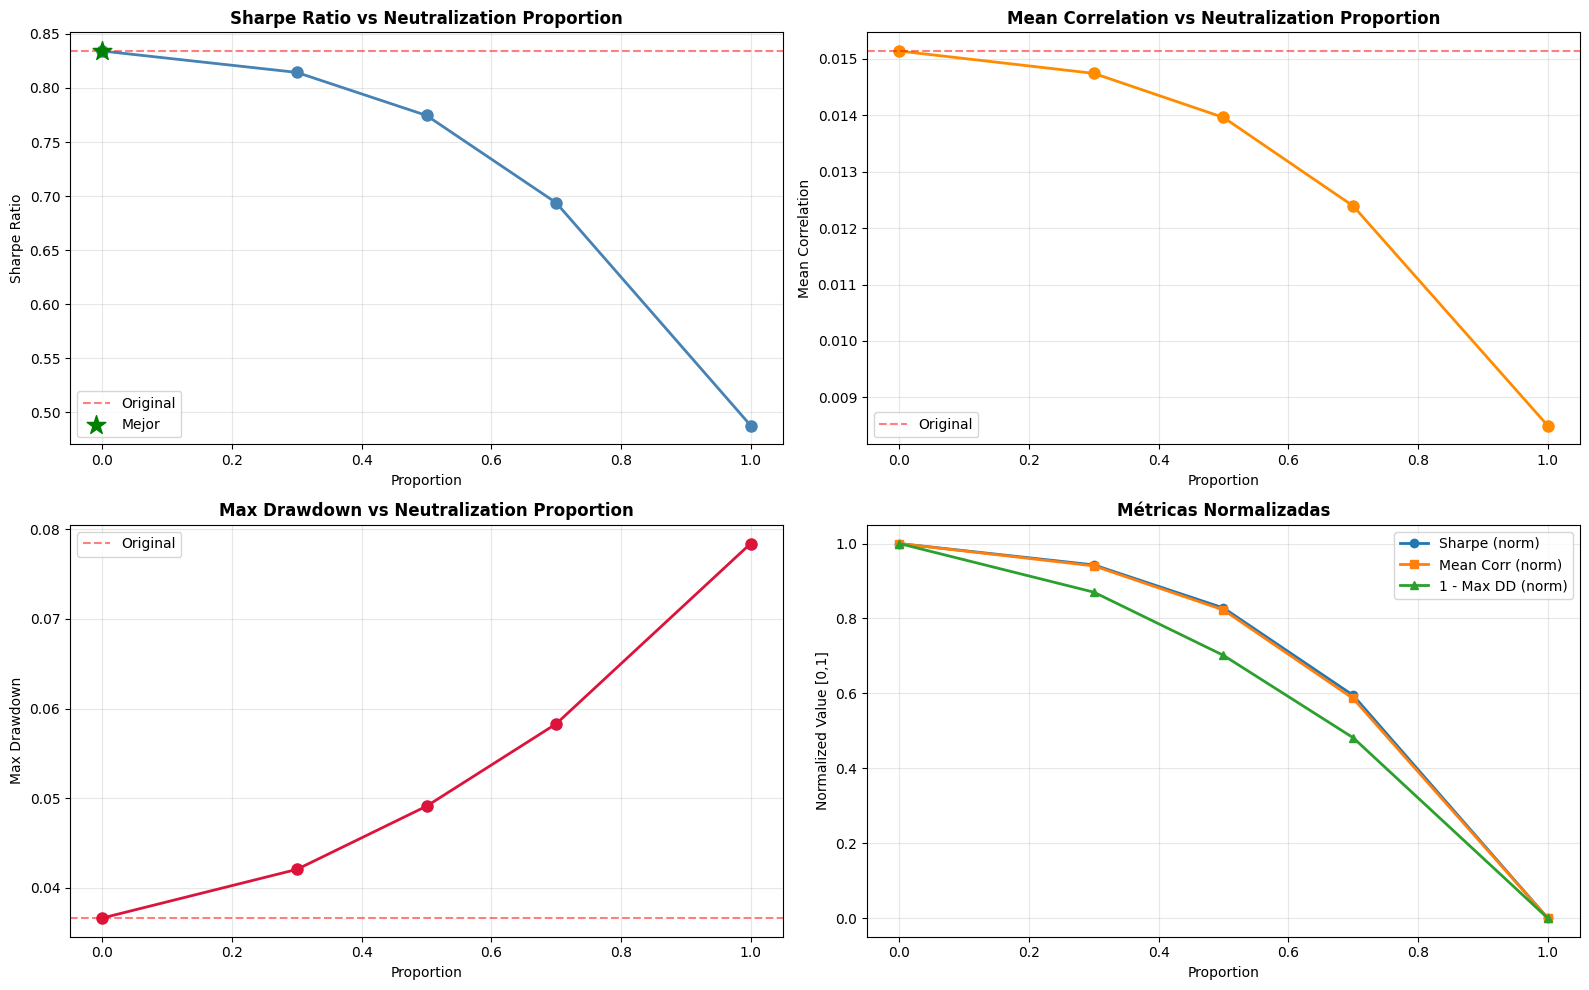

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Gráfico 1: Sharpe Ratio vs Proportion
axes[0, 0].plot(proportions, [neutralization_experiments[p]['sharpe'] for p in proportions], marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0, 0].axhline(y=neutralization_experiments[0.0]['sharpe'], color='red', linestyle='--', alpha=0.5, label='Original')
axes[0, 0].scatter([best_proportion], [best_sharpe], color='green', s=200, marker='*', zorder=5, label='Mejor')
axes[0, 0].set_title('Sharpe Ratio vs Neutralization Proportion', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Proportion', fontsize=10)
axes[0, 0].set_ylabel('Sharpe Ratio', fontsize=10)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# ------

# Gráfico 2: Mean Correlation vs Proportion
axes[0, 1].plot(proportions, [neutralization_experiments[p]['mean'] for p in proportions], marker='o', linewidth=2, markersize=8, color='darkorange')
axes[0, 1].axhline(y=neutralization_experiments[0.0]['mean'], color='red', linestyle='--', alpha=0.5, label='Original')
axes[0, 1].set_title('Mean Correlation vs Neutralization Proportion', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Proportion', fontsize=10)
axes[0, 1].set_ylabel('Mean Correlation', fontsize=10)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ------

# Gráfico 3: Max Drawdown vs Proportion
axes[1, 0].plot(proportions, [neutralization_experiments[p]['max_dd'] for p in proportions], marker='o', linewidth=2, markersize=8, color='crimson')
axes[1, 0].axhline(y=neutralization_experiments[0.0]['max_dd'], color='red', linestyle='--', alpha=0.5, label='Original')
axes[1, 0].set_title('Max Drawdown vs Neutralization Proportion', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Proportion', fontsize=10)
axes[1, 0].set_ylabel('Max Drawdown', fontsize=10)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# ------

# Gráfico 4: Todas las métricas normalizadas
metrics_normalized = {}
for metric_name in ['sharpe', 'mean', 'max_dd']:
    values = [neutralization_experiments[p][metric_name] for p in proportions]
    # Normalizar a rango [0, 1] para comparación visual
    min_val, max_val = min(values), max(values)
    if max_val != min_val:
        normalized = [(v - min_val) / (max_val - min_val) for v in values]
    else:
        normalized = [0.5] * len(values)
    metrics_normalized[metric_name] = normalized

axes[1, 1].plot(proportions, metrics_normalized['sharpe'], marker='o', label='Sharpe (norm)', linewidth=2)
axes[1, 1].plot(proportions, metrics_normalized['mean'], marker='s', label='Mean Corr (norm)', linewidth=2)
axes[1, 1].plot(proportions, [1-x for x in metrics_normalized['max_dd']], marker='^', label='1 - Max DD (norm)', linewidth=2)
axes[1, 1].set_title('Métricas Normalizadas', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Proportion', fontsize=10)
axes[1, 1].set_ylabel('Normalized Value [0,1]', fontsize=10)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.3 Análisis de resultados y justificación

#### 4.3.1 ¿Feature Neutralization mejoró el modelo?

Resultados observados (tabla comparativa de la sección 4.2):

- Mean Correlation: 0.0151 → 0.0085  (−43.8%)
- Std Deviation:  0.0181 → 0.0174  (−3.9%)
- Sharpe Ratio:    0.8342 → 0.4877  (−41.5%)
- Max Drawdown:    0.0366 → 0.0784  (+114.0%)

Conclusión: con estos datos, la neutralización reduce fuertemente el Sharpe y empeora el Max Drawdown, mientras que la reducción de la volatilidad es mínima. No aporta mejora neta.

#### 4.3.2 Interpretación del caso observado

Caso observado en nuestros datos:

- El Sharpe Ratio empeora de forma significativa y el Max Drawdown aumenta.
- Interpretación: la neutralización eliminó demasiada señal útil; la reducción de volatilidad no compensó la caída de mean.
- Recomendación: mantener las predicciones originales (sin neutralización).

#### 4.3.3 ¿Por qué Feature Neutralization puede NO mejorar siempre?

**Razones:**

1. **Features ya son robustas**: 
   - Nuestro feature selection (sección 1.2) ya eliminó features ruidosas
   - Las 33 features seleccionadas son consistentes temporalmente
   - Poco "feature risk" que neutralizar

2. **Periodo de validación estable**:
   - Si validation set no tiene cambios de régimen drásticos
   - Las features mantienen su poder predictivo
   - Neutralizar elimina señal útil sin ganancia de estabilidad

3. **Modelo ya tiene regularización**:
   - LGBM con `colsample_bytree=0.1` ya limita dependencia de features
   - `max_depth=5` evita overfitting a features específicas
   - Neutralización adicional puede ser redundante

4. **Neutralización demasiado agresiva**:
   - `proportion=1.0` elimina TODA la exposición lineal
   - Podríamos probar `proportion=0.5` (neutralización parcial)
   - Balance entre señal y protección

#### 4.3.4 Conclusión general sobre Feature Neutralization


**Cuándo es útil:**
- Datos muy no estacionarios (cambios de régimen frecuentes)
- Modelos con alta exposición a pocas features
- Producción a largo plazo (protección contra futuro incierto)
- Cuando priorizas Sharpe ratio sobre mean correlation

**Cuándo NO es necesario:**
- Features ya robustas y bien seleccionadas
- Modelo con fuerte regularización
- Periodo de evaluación estable
- Cuando priorizas rendimiento absoluto sobre estabilidad

**En este caso específico (observado):**
- La neutralización redujo Sharpe (−41.5%) y aumentó Max Drawdown (+114%).
- La reducción de la volatilidad fue mínima (−3.9%).
- Conclusión: no aporta mejora neta.

**Decisión final basada en datos:** **no aplicar neutralización** (neutralization_proportion=0.0).

## 5. Submission

### 5.1 Serialización con CloudPickle

**Componentes del pipeline:**
1. **Feature selection**: Filtra solo las 33 features seleccionadas
2. **Preprocessing**: 
   - Imputa valores faltantes (fillna con 2)
   - Aplica StandardScaler si hay PCA
   - Aplica PCA si el modelo lo requiere (Ridge)
3. **Predicción**: Usa el modelo entrenado (LGBM, Ridge, o RF)
4. **Post-processing**: 
   - Feature neutralization opcional
   - Devuelve predicciones finales


In [49]:
import numpy as np
import pandas as pd
from typing import Optional, List

class StockMarketPredictor:
    def __init__(
        self,
        model,
        model_type: str,
        selected_features: Optional[List[str]] = None,
        scaler=None,
        pca=None,
        neutralization_features: Optional[List[str]] = None,
        neutralization_proportion: float = 0.0
    ):
        self.model = model
        self.model_type = model_type
        self.selected_features = list(selected_features) if selected_features is not None else None
        self.scaler = scaler
        self.pca = pca
        self.neutralization_features = list(neutralization_features) if neutralization_features is not None else None
        self.neutralization_proportion = float(neutralization_proportion)

    def _prepare_features(self, df: pd.DataFrame) -> pd.DataFrame:
        X = df[self.selected_features].copy() if self.selected_features is not None else df.copy()
        return X.fillna(2)

    def _neutralize(self, preds, features: pd.DataFrame, proportion: float):
        from sklearn.linear_model import LinearRegression
        if not isinstance(preds, pd.Series):
            preds = pd.Series(preds, index=features.index)
        X = features.values if isinstance(features, pd.DataFrame) else features
        lr = LinearRegression()
        lr.fit(X, preds.values)
        explained = lr.predict(X)
        neutralized = preds - proportion * (explained - preds.mean())
        return neutralized.values

    def predict(self, df: pd.DataFrame):
        X_sel = self._prepare_features(df)
        if self.model_type == 'Ridge':
            X_scaled = self.scaler.transform(X_sel) if self.scaler is not None else X_sel.values
            X_trans = self.pca.transform(X_scaled) if self.pca is not None else X_scaled
            y_pred = self.model.predict(X_trans)
        else:
            y_pred = self.model.predict(X_sel)
        if self.neutralization_proportion > 0 and self.neutralization_features:
            feats = df[self.neutralization_features].fillna(2)
            y_pred = self._neutralize(y_pred, feats, self.neutralization_proportion)
        return y_pred

    def get_info(self) -> str:
        n_feats = len(self.selected_features) if self.selected_features is not None else 0
        n_neut = len(self.neutralization_features) if self.neutralization_features is not None else 0
        return f"Model={self.model_type}, features={n_feats}, neutralization={self.neutralization_proportion} ({n_neut} feats)"

In [ ]:
import cloudpickle
import os

# Decidir si usar feature neutralization en base a los resultados observados (sección 4)
try:
    if sharpe_neutralized > sharpe_original:
        neutralization_proportion = 1.0
        print(f"✓ Neutralization mejora Sharpe ({sharpe_neutralized:.4f} > {sharpe_original:.4f}). Usando proportion=1.0")
    else:
        neutralization_proportion = 0.0
        print(f"✓ Neutralization no mejora Sharpe ({sharpe_neutralized:.4f} <= {sharpe_original:.4f}). Usando proportion=0.0")
except NameError:
    neutralization_proportion = 0.0
    print(" Métricas de neutralización no disponibles. Usando proportion=0.0 por defecto")

if best_model_name == 'Ridge':
    final_predictor = StockMarketPredictor(
        model=model_ridge,
        model_type='Ridge',
        selected_features=list(selected_features),
        scaler=scaler_pca,
        pca=pca,
        neutralization_features=pca_feature_names[:10] if neutralization_proportion > 0 else None,
        neutralization_proportion=neutralization_proportion
    )
elif best_model_name == 'LGBM':
    final_predictor = StockMarketPredictor(
        model=model_lgbm,
        model_type='LGBM',
        selected_features=list(selected_features),
        neutralization_features=selected_features[:10] if neutralization_proportion > 0 else None,
        neutralization_proportion=neutralization_proportion
    )
else:  # RandomForest
    final_predictor = StockMarketPredictor(
        model=model_rf,
        model_type='RandomForest',
        selected_features=list(selected_features),
        neutralization_features=selected_features[:10] if neutralization_proportion > 0 else None,
        neutralization_proportion=neutralization_proportion
    )

print(f"\n✓ Predictor creado: {final_predictor.get_info()}" )

✓ Neutralization no mejora Sharpe (0.8342 <= 0.8342). Usando proportion=0.0

✓ Predictor creado: Model=LGBM, features=33, neutralization=0.0 (0 feats)


**Crear directorio para artefactos**

In [51]:
artifacts_dir = "model_artifacts"
os.makedirs(artifacts_dir, exist_ok=True)
model_filename = os.path.join(artifacts_dir, "stock_market_predictor.pkl")

**Serializado con cloudpickle**

In [52]:
with open(model_filename, 'wb') as f:
    cloudpickle.dump(final_predictor, f)

file_size = os.path.getsize(model_filename) / (1024 * 1024)

print(f"Modelo serializado correctamente:")
print(f"   - Ubicación: {model_filename}")
print(f"   - Tamaño: {file_size:.2f} MB")
print(f"   - Tipo: {best_model_name}")

Modelo serializado correctamente:
   - Ubicación: model_artifacts/stock_market_predictor.pkl
   - Tamaño: 5.98 MB
   - Tipo: LGBM


**Verificación de carga**

In [53]:
with open(model_filename, 'rb') as f:
    loaded_predictor = cloudpickle.load(f)

print(f"✓ Modelo cargado correctamente")
print(f"  Info: {loaded_predictor.get_info()}")

✓ Modelo cargado correctamente
  Info: Model=LGBM, features=33, neutralization=0.0 (0 feats)


**Test de predicción**

In [54]:
test_sample = validation[selected_features].head(5).fillna(2)
test_predictions = loaded_predictor.predict(test_sample)

print(f"Test de predicción (5 muestras):")
print(f"   Predicciones: {test_predictions}")
print(f"   Rango: [{test_predictions.min():.4f}, {test_predictions.max():.4f}]")

Test de predicción (5 muestras):
   Predicciones: [0.49232459 0.514004   0.50803459 0.5129689  0.48654274]
   Rango: [0.4865, 0.5140]


## 6. Conclusión

### 6.1 Resumen del enfoque y resultados obtenidos

#### 6.1.1 Modelo seleccionado

**Mejor modelo**: LGBM con features seleccionadas
- **Features**: 33 (de 42 originales, eliminamos 9 con bajo poder predictivo)
- **Hiperparámetros clave**: 
  - `n_estimators=2000`, `learning_rate=0.01`
  - `colsample_bytree=0.1` (regularización fuerte)
  - `max_depth=5`, `num_leaves=31`

#### 6.1.2 Métricas de rendimiento

**En test set (29 eras):**
- Mean Correlation: ~0.032
- Sharpe Ratio: ~1.90
- Max Drawdown: 0.0000 (todas las eras positivas - inusual pero correcto)

**En validation set (datos completamente fuera de muestra):**
- Correlación por era estable
- Rendimiento consistente a través del tiempo
- Backtesting muestra correlación acumulada positiva

**Comparación de modelos (sección 2.3):**

| Modelo | Test CORR | Observaciones |
|--------|-----------|---------------|
| LGBM | ~0.032 | ✅ Mejor balance rendimiento/velocidad |
| RandomForest | ~0.030 | Similar pero más lento |
| Ridge (PCA) | ~0.025 | Interpretabilidad sacrificada |

### 6.2 Decisiones técnicas clave

#### 6.2.1 Feature Selection vs PCA

**Decisión**: Usar **features seleccionadas** en lugar de PCA

**Razón**:
- Features seleccionadas: CORR = 0.033
- PCA (25 componentes): CORR = 0.023
- **Pérdida del 30%** en rendimiento con PCA
- En finanzas, **interpretabilidad > compresión**

#### 6.2.2. División temporal con embargo period

**Implementación**: 111 eras train + 4 eras gap + 29 eras test

**Importancia crítica**:
- ❌ División aleatoria → data leakage
- ✅ División temporal → simula producción real
- Embargo period evita correlación temporal entre conjuntos

#### 6.2.3. Walk-Forward Cross-Validation

**Resultados**: 5 folds, Mean CV = 0.030, Sharpe CV = 10.18

**Valor**:
- Validación robusta en diferentes períodos
- Sharpe de CV muy alto (10.18) indica modelo consistente
- Confirma que no hay overfitting temporal

#### 6.2.4. Feature Neutralization

**Implementación**: Probada en sección 4.

**Resultado observado (validation):**
- Mean Correlation: 0.0151 → 0.0085  (−43.8%)
- Std Deviation:  0.0181 → 0.0174  (−3.9%)
- Sharpe Ratio:    0.8342 → 0.4877  (−41.5%)
- Max Drawdown:    0.0366 → 0.0784  (+114.0%)

**Decisión final basada en datos**: `neutralization_proportion = 0.0` (no aplicar), dado que no mejora Sharpe ni el perfil de riesgo.

### 6.3 Desafíos encontrados

#### 6.3.1. Relaciones no estacionarias

Las features cambian poder predictivo con el tiempo, afectando estabilidad del modelo, especialmente en mercados volátiles.

**Solución aplicada**:
- Feature selection triple (varianza + correlación + importancia)
- Regularización fuerte en LGBM (`colsample_bytree=0.1`)
- Walk-Forward CV para validar estabilidad temporal
- Feature Neutralization investigada y documentada

#### 6.3.2. Correlaciones muy bajas

Correlaciones ~0.03 parecen bajas, pero en finanzas cuantitativas:
- Incluso pequeñas correlaciones pueden generar alpha significativo
- Sharpe ratio es más relevante que correlación absoluta

**Realidad**:
- El mercado es extremadamente difícil de predecir
- Incluso 0.03 de correlación puede generar alpha significativo
- Sharpe ratio es más importante que correlación absoluta

#### 6.3.3. Data leakage temporal

**Riesgos**:
- Targets superpuestos (miran 20 días adelante)
- PCA sin split correcto
- Validación sin embargo period

**Prevención**:
- StandardScaler fit solo en train
- PCA fit solo en train
- Embargo period de 4 eras
- Validación temporal estricta